In [2]:
print("Started................")

Started................


In this Notebook, 

I am trying to use BDR (Bi-Dimensional Regression) on our Sketchmaps.
Rather than being a statistic, BDR is more like a framework, where multiple statistical measures are used. #

These statistical measures are as follows:

1. r -> Correlation coefficient (This shows how the map overall looks like)
2. R^2 -> Covariance (How well is everything placed in the sketchmap)
3. DI -> Distortion Index (from 0 to 100, shows how messy a drawing is, or how distorted is a sketchmap.)
4. Alpha 1 -> Horizontal shift (did the person shift all the building in the east?) Negative value indicates West
5. Alpha 2 -> Vertical shift (did the person shift all the buildings in the North? ) Negative value indicates south
6. Theta -> Rotation Angle (shows whether the whole sketchmap is rotated by a certail angle)
7. phi -> scale (shows whether the things in sketchmap are larger or smaller than the basemap.)

These measures constitutes BDR (Bi - Dimensional Regression).

BDR always works on 2 points or in this case polygons (which are also being denoted by points in this case). 

Now, these measures are ran individualy on a pair (one point in Basemap and another in sketchmap) and then all of these values are averaged by all of the buildings in the sketchmap. 




In [3]:
import geopandas as gpd
import json
import matplotlib.pyplot as plt

    id isRoute feat_type  selected  aligned    otype  RouteSeqOrder  missing  \
24  24     NaN  Landmark     False     True  Polygon            NaN      NaN   
25  25     NaN  Landmark     False     True  Polygon            NaN      NaN   
26  26     NaN  Landmark     False     True  Polygon            NaN      NaN   
27  27     NaN  Landmark     False     True  Polygon            NaN      NaN   
28  28     NaN  Landmark     False     True  Polygon            NaN      NaN   
29  29     NaN  Landmark     False     True  Polygon            NaN      NaN   
30  30     NaN  Landmark     False     True  Polygon            NaN      NaN   
31  31     NaN  Landmark     False     True  Polygon            NaN      NaN   
32  32     NaN  Landmark     False     True  Polygon            NaN      NaN   
33  33     NaN  Landmark     False     True  Polygon            NaN      NaN   

                                             geometry  
24  POLYGON ((216.5 475.8, 238.5 476.3, 243 525.3,...  
25  POL

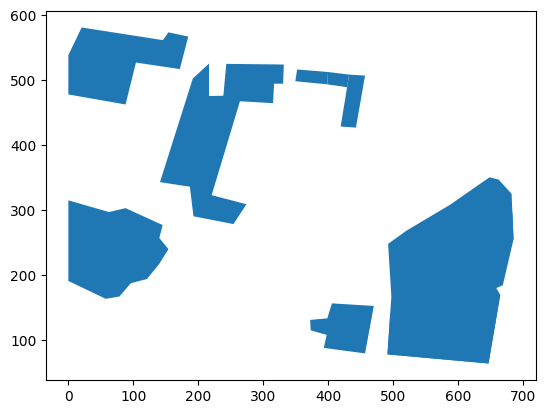

In [4]:
bsm_feat = gpd.read_file("./datasets/sketchmap-bdr-test/basemap.jpg.geojson")
bsm_landmarks  = bsm_feat[bsm_feat['feat_type'] == 'Landmark']


print(bsm_landmarks)
bsm_landmarks.plot()
ax = plt.gca()
ax.set_aspect('equal')

    id  sid isRoute feat_type  selected  aligned    otype  \
22  22  S22     NaN  Landmark     False     True  Polygon   
23  23  S23     NaN  Landmark     False     True  Polygon   
24  24  S24     NaN  Landmark     False     True  Polygon   
25  25  S25     NaN  Landmark     False     True  Polygon   
26  26  S26     NaN  Landmark     False     True  Polygon   
27  27  S27     NaN  Landmark     False     True  Polygon   
28  28  S28     NaN  Landmark     False     True  Polygon   
29  29  S29     NaN  Landmark     False     True  Polygon   
30  30  S30     NaN  Landmark     False     True  Polygon   
31  31  S31     NaN  Landmark     False     True  Polygon   
32  32  S32     NaN  Landmark     False    False  Polygon   

    SketchRouteSeqOrder                                           geometry  
22                  NaN  POLYGON ((58.72684 467.50384, 94.71718 475.003...  
23                  NaN  POLYGON ((142.70431 397.00804, 172.60598 392.0...  
24                  NaN  POLYGON ((2

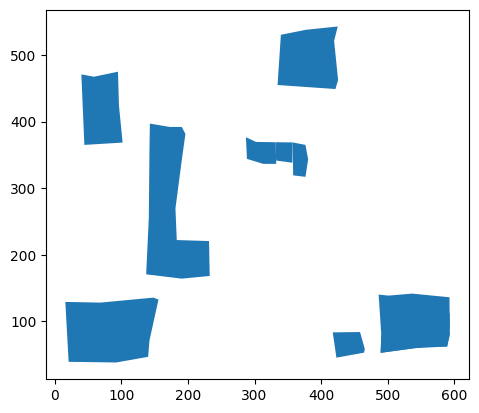

In [5]:
skm_feat = gpd.read_file("./datasets/sketchmap-bdr-test/sketchMap1.JPG.geojson")



skm_landmarks = skm_feat[skm_feat['feat_type'] == 'Landmark']
print(skm_landmarks)
skm_landmarks.plot()
ax = plt.gca()
ax.set_aspect('equal')

In [6]:
with open('./datasets/alignm/alignment.json', 'r') as file:
    align = json.load(file)


print(align['sketchMap1.JPG'])

sketchmap1_align = align['sketchMap1.JPG']

{'1': {'BaseAlign': {'0': [0]}, 'SketchAlign': {'0': ['S0']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '2': {'BaseAlign': {'0': [1]}, 'SketchAlign': {'0': ['S1']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '3': {'BaseAlign': {'0': [2]}, 'SketchAlign': {'0': ['S2']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '4': {'BaseAlign': {'0': [3]}, 'SketchAlign': {'0': ['S3']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '5': {'BaseAlign': {'0': [4]}, 'SketchAlign': {'0': ['S4']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '6': {'BaseAlign': {'0': [6]}, 'SketchAlign': {'0': ['S5']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '7': {'BaseAlign': {'0': [7]}, 'SketchAlign': {'0': ['S6']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '8': {'BaseAlign': {'0': [8]}, 'SketchAlign': {'0': ['S7']}, 'genType': 'No generalization', 'degreeOfGeneralization': 0}, '9': {'BaseAlig

I have three files now: 
        1. Basemap GeoJSON file
        2. Sketchmap GeoJSON file
        3. Alignment JSON file

Alignment file contains how I the landmarks in Basemap are connected to Sketchmap. 

So, there is a key in Sketchmap GeoJSON 'sid' which is mentioned in Alignment file and also an id of Basemap.

This will help us match Landmarks in these files. 

In [7]:
from skimage import transform 
import numpy as np
import sys


base_pts = []
sketch_pts = []
pair_labels = []

for key, value in sketchmap1_align.items():
    if key == "checkAlignnum":
        continue

    base_indices = value['BaseAlign']['0']
    sketch_sids = value['SketchAlign']['0']

    s_id = sketch_sids[0]

    
    s_feat = skm_landmarks[skm_landmarks['sid'] == s_id]
    b_feat = bsm_landmarks[bsm_landmarks['id'].isin(base_indices)]

    if not s_feat.empty and not b_feat.empty:
        s_centroid = s_feat.geometry.representative_point().values[0]
        sketch_pts.append([s_centroid.x, s_centroid.y])

        b_centroids = b_feat.geometry.representative_point()
        mean_x = b_centroids.x.mean()
        mean_y = b_centroids.y.mean()
        base_pts.append([mean_x, mean_y])
#We are using the representative point of the geometry to get a single point for each feature,
#and then we average the x and y coordinates because of generalization of multiple features in teh base map.
#This way we can get a single point for multiple features in the basemap which then aligns with single features in the sketchmap.




X = np.array(base_pts)
Y = np.array(sketch_pts)

tform = transform.SimilarityTransform()
tform.estimate(X,Y)

print("BDR Complete")
print(f" {len(X)} valid alignment pairs.")
print(f" Scale: {tform.scale:.4f}")
print(f" Rotation: {np.degrees(tform.rotation):.2f}")

BDR Complete
 10 valid alignment pairs.
 Scale: 0.8745
 Rotation: 2.01


C:\Users\Clément\AppData\Local\Temp\ipykernel_20288\1492090222.py:42: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(X,Y)


In the cell above, 

I have taken three lists: 
1. base_pts (stores the points from basemap)
2. sketch_pts (stores the points from sketchmap) and 
3. pair_labels (stores the pairs which are common in basemap and sketchmap)


Then, extract the pairs from the alignment file. 
Where, the common landmarks are matched using, 

'id' from basemap
'sid' from sketchmap

Now, we extract where both id and sid are not empty, giving us the common polygons. 
After this, I take the building id from basemap and sketchmap (they are already aligned) and draw a centroid using the geometry of the buildings in sketchmap.

For basemap, we use representative point, which makes sure the centre point of our building is always inside the building and not out. Since, the buildings in the basemap can have complex shapes, which might include a lot of corners or vertices. 


Then, we store all those points from basemap in X (ground truth), which is the independent variable and 
we store all the points from sketchmap in Y (drawn by user), is the dependent variable. 

WE store them into numpy array, because that is the acceptable format for BDR.


Then we use the SimilarityTransfrom function, which matches how well these two maps match, but movement, rotation and scaling the basemap is allowed to make it fit the sketchmap.


After that, the function find the best rotation, the best scale and the best shift, which results in the smallest possible distrance betweeen the ground truth and the corresponding sketchmaps.

# BDR

C:\Users\Clément\AppData\Local\Temp\ipykernel_20288\1194543446.py:34: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(X, Y)


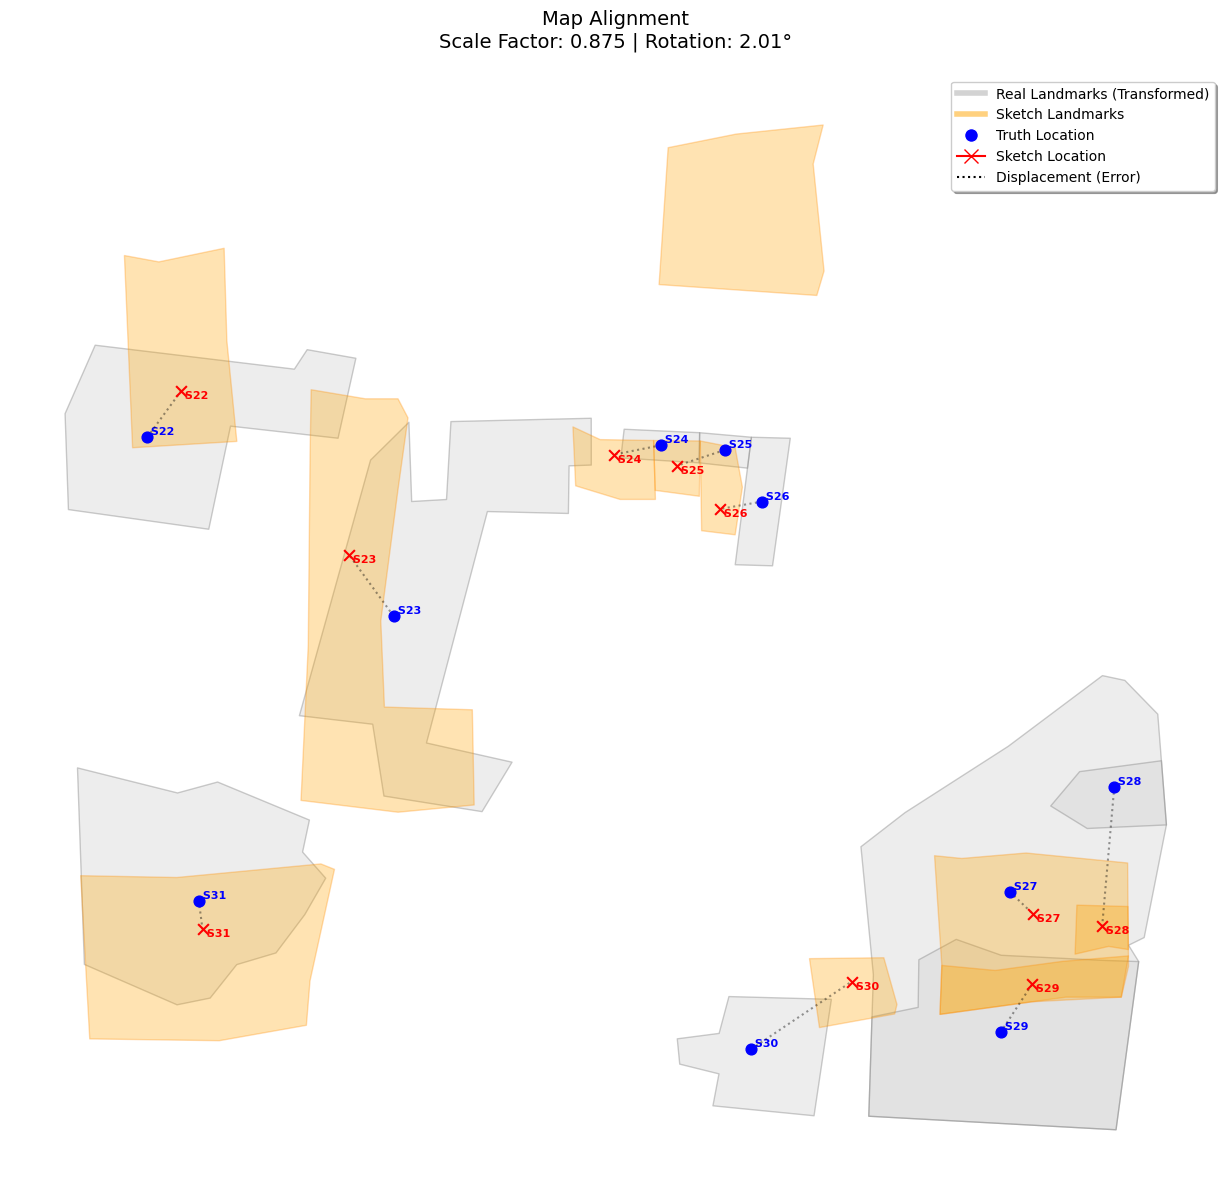

In [8]:
import matplotlib.pyplot as plt
from skimage import transform
from shapely.affinity import affine_transform
import numpy as np

# --- 1. DATA PROCESSING & SYNCHRONIZATION ---
base_pts = []
sketch_pts = []
pair_labels = []

for key, value in sketchmap1_align.items():
    if key == "checkAlignnum": continue
    
    b_indices = value['BaseAlign']['0']
    s_sid = value['SketchAlign']['0'][0]
    
    b_feats = bsm_landmarks[bsm_landmarks['id'].isin(b_indices)]
    s_feat = skm_landmarks[skm_landmarks['sid'] == s_sid]
    
    if not s_feat.empty and not b_feats.empty:
        # Use representative_point to ensure dots stay inside building footprints
        b_point = b_feats.geometry.representative_point()
        base_pts.append([b_point.x.mean(), b_point.y.mean()])
        
        s_point = s_feat.geometry.representative_point().values[0]
        sketch_pts.append([s_point.x, s_point.y])
        pair_labels.append(s_sid) 

X = np.array(base_pts)
Y = np.array(sketch_pts)

# --- 2. BIDIMENSIONAL REGRESSION ---
tform = transform.SimilarityTransform()
tform.estimate(X, Y)
predicted_Y = tform(X)

# --- 3. GEOMETRY TRANSFORMATION ---
# Move the Real Landmarks into Sketch Space so they overlap for the plot
m = tform.params
matrix = [m[0,0], m[0,1], m[1,0], m[1,1], m[0,2], m[1,2]]
bsm_transformed = bsm_landmarks.copy()
bsm_transformed['geometry'] = bsm_transformed['geometry'].apply(lambda x: affine_transform(x, matrix))

# IMPORTANT: Strip CRS to prevent "aspect must be finite" error
bsm_transformed.crs = None
skm_landmarks.crs = None

# --- 4. PLOTTING ---
fig, ax = plt.subplots(figsize=(14, 12))
ax.set_aspect('equal')

# Plot Polygons
bsm_transformed.plot(ax=ax, color='lightgray', edgecolor='gray', alpha=0.4, label='Real World (Projected)')
skm_landmarks.plot(ax=ax, color='orange', edgecolor='darkorange', alpha=0.3, label='User Sketch')

# Plot Dots
# We plot the first one with a label for the legend, then loop the rest
ax.scatter(predicted_Y[:, 0], predicted_Y[:, 1], color='blue', s=60, marker='o', 
           label='Truth Anchor (Blue)', zorder=5)
ax.scatter(Y[:, 0], Y[:, 1], color='red', s=60, marker='x', 
           label='Sketch Anchor (Red)', zorder=5)

# Plot Labels and Connectors
for i in range(len(Y)):
    label = pair_labels[i]
    
    # Label the Blue Dot
    ax.text(predicted_Y[i, 0], predicted_Y[i, 1], f" {label}", 
            color='blue', fontsize=8, fontweight='bold', va='bottom')
    
    # Label the Red Dot
    ax.text(Y[i, 0], Y[i, 1], f" {label}", 
            color='red', fontsize=8, fontweight='bold', va='top')
    
    # Connector line (Error Vector)
    line, = ax.plot([predicted_Y[i, 0], Y[i, 0]], [predicted_Y[i, 1], Y[i, 1]], 
                    color='black', linestyle=':', alpha=0.4, zorder=4)

# Formatting
plt.title(f"Map Alignment\nScale Factor: {tform.scale:.3f} | Rotation: {np.degrees(tform.rotation):.2f}°", 
          fontsize=14, pad=20)

# Manually handle legend because geopandas.plot and ax.scatter work differently
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='lightgray', lw=4, label='Real Landmarks (Transformed)'),
    Line2D([0], [0], color='orange', lw=4, alpha=0.5, label='Sketch Landmarks'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Truth Location'),
    Line2D([0], [0], marker='x', color='red', markersize=10, label='Sketch Location'),
    Line2D([0], [0], color='black', linestyle=':', label='Displacement (Error)')
]
ax.legend(handles=legend_elements, loc='upper right', frameon=True, shadow=True)

ax.set_axis_off()
plt.tight_layout()
plt.show()

In [9]:
print(predicted_Y)

[[ 52.40529418 370.94139498]
 [188.12214348 272.22717864]
 [335.50960321 366.36551031]
 [370.69887399 363.72747514]
 [391.52784253 335.36280937]
 [528.09397878 120.07922856]
 [585.58635892 177.87920562]
 [522.88195487  42.5892063 ]
 [385.50383992  33.48134532]
 [ 80.72515443 115.32888876]]


## DI (Distortion Index)

In [10]:
from sklearn.metrics import r2_score
r2 = r2_score(Y, predicted_Y)
distortion_index = 100 * np.sqrt(1 - r2)
print(f"Distortion Index: {distortion_index:.2f}")

Distortion Index: 19.85


## Translation

In [11]:
alpha1 = tform.translation[0]
alpha2 = tform.translation[1]
print(f"Alpha 1 (X-Shift): {alpha1:.2f}")
print(f"Alpha 2 (Y-Shift): {alpha2:.2f}")

Alpha 1 (X-Shift): 23.51
Alpha 2 (Y-Shift): -87.11


## Correlation Coefficient (r)

In [12]:
from sklearn.metrics import r2_score
r2 = r2_score(Y, predicted_Y)
r = np.sqrt(r2)
print(f"Bidimensional Correlation (r): {r:.4f}")

Bidimensional Correlation (r): 0.9801


## Rotation 

In [13]:
# Convert radians to degrees
rotation_deg = np.degrees(tform.rotation)
print(f"Rotation (Theta): {rotation_deg:.2f}°")

Rotation (Theta): 2.01°


# GARDONY BASED - MEASURES

In [ ]:
import matplotlib.pyplot as plt
from skimage import transform
from shapely.affinity import affine_transform
import geopandas as gpd
import pandas as pd
import numpy as np
import json
import math


# TO CHOOSE
mode = 'advanced'
skm_id = 1

base_pts = []
sketch_pts = []
landmark_ids = []
pair_labels = []

if mode == 'basic':
    skm_feat = gpd.read_file("./datasets/sketchmap-bdr-test/sketchMap" + str(skm_id) + ".JPG.geojson")
    skm_landmarks = skm_feat[skm_feat['feat_type'] == 'Landmark']
    bsm_feat = gpd.read_file("./datasets/sketchmap-bdr-test/basemap.jpg.geojson")
    bsm_landmarks  = bsm_feat[bsm_feat['feat_type'] == 'Landmark']
    with open('./datasets/alignm/alignment.json', 'r') as file:
        align = json.load(file)
    sketchmap_align = align["sketchMap" + str(skm_id) + ".JPG"]

    for key, value in sketchmap_align.items():
        if key == "checkAlignnum": continue
        
        b_indices = value['BaseAlign']['0']
        s_sid = value['SketchAlign']['0'][0]
        
        b_feats = bsm_landmarks[bsm_landmarks['id'].isin(b_indices)]
        s_feat = skm_landmarks[skm_landmarks['sid'] == s_sid]

        if not b_feats.empty and not s_feat.empty:
            # Use representative_point to ensure dots stay inside building footprints
            b_point = b_feats.geometry.representative_point()
            base_pts.append([b_point.x.mean(), b_point.y.mean()])

            s_point = s_feat.geometry.representative_point().values[0]
            sketch_pts.append([s_point.x, s_point.y])
            pair_labels.append(s_sid)
    
elif mode == 'advanced':
    bsm_df = pd.read_csv("./datasets/rectangle-coords/rect_coords_bsm.csv")
    skm_df = pd.read_csv("./datasets/rectangle-coords/rect_coords_skm" + str(skm_id) + ".csv")
    
    for i in range(bsm_df.shape[0]):
        base_pts.append(bsm_df[['X', 'Y']].iloc[i])
        landmark_ids.append(bsm_df[['landmarkName']].iloc[i])
        if skm_df['X'].isna()[i]:
            sketch_pts.append([None, None]) # missing landmark
        else:
            sketch_pts.append(skm_df[['X', 'Y']].iloc[i])

X = np.array(base_pts)
Y = np.array(sketch_pts)
landmark_ids = np.array(landmark_ids)

nTL = 10 # number of landmarks on the base map
if mode == 'basic':
    nDL = len(Y) # number of landmarks on the sketch map
elif mode == 'advanced':
    nDL = 0
    for i in range(Y.shape[0]):
        if Y[i, 0] != None:
            nDL += 1
    nDL = nDL // 8

if mode == 'basic':
    n_nTL = math.comb(nTL, 2)
    n_nDL = math.comb(nDL, 2)
elif mode == 'advanced':
    n_nTL = math.comb(8*nTL, 2) - nTL*math.comb(8, 2)
    n_nDL = math.comb(8*nDL, 2) - nDL*math.comb(8, 2)

## Canonical Measures

### Canonical Organization (CanOrg)

In [53]:
sum_can_score = 0

for i in range(len(Y)):
    b1, s1 = X[i], Y[i] # current landmark on base map & sketch map
    if s1[0] != None: # not a missing landmark
        for j in range(i+1, len(Y)): # for every other landmark
            if mode == 'advanced' and landmark_ids[j, 0] == landmark_ids[i, 0]: # ignore comparison if points on the same landmark
                continue
            b2, s2 = X[j], Y[j]
            if s2[0] != None:
                # NS comparison
                if (b1[1] < b2[1] and s1[1] < s2[1]) or (b1[1] > b2[1] and s1[1] > s2[1]):
                    sum_can_score += 1
                # EW comparison
                if (b1[0] < b2[0] and s1[0] < s2[0]) or (b1[0] > b2[0] and s1[0] > s2[0]):
                    sum_can_score += 1

can_org = sum_can_score / (2*n_nTL)
print(f"CanOrg = {can_org}")

CanOrg = 0.07170138888888888


| Sketchmap | Computed CanOrg (B) | GMDA CanOrg (B) | Computed CanOrg (A) | GMDA CanOrg (A) | d_CanOrg (B) | d_CanOrg (A)
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
| **1** | 0.96 | 0.96 | 0.95 | 0.95 | 0.00 | 0.00 |
| **2** | 0.96 | 0.93 | 0.93 | 0.93 | 0.03 | 0.00 |
| **3** | 0.12 | 0.11 | 0.12 | 0.12 | 0.01 | 0.00 |
| **4** | 0.01 | 0.01 | 0.01 | 0.01 | 0.00 | 0.00 |
| **5** | 0.01 | 0.01 | 0.01 | 0.01 | 0.00 | 0.00 |
| **6** | 0.12 | 0.19 | 0.20 | 0.20 | 0.07 | 0.00 |
| **7** | 0.44 | 0.56 | 0.56 | 0.56 | 0.12 | 0.00 |
| **8** | 0.19 | 0.20 | 0.18 | 0.18 | 0.01 | 0.00 |
| **9** | 0.03 | 0.06 | 0.06 | 0.06 | 0.03 | 0.00 |

* Mean d_CanOrg (B): **0.03**
* Mean d_CanOrg (A): **0.00**

### Canonical Accuracy (CanAcc)

In [ ]:
sum_can_score = 0

for i in range(len(Y)):
    b1, s1 = X[i], Y[i] # current landmark on base map & sketch map
    if s1[0] != None: # not a missing landmark
        for j in range(i+1, len(Y)): # for every other landmark
            if mode == 'advanced' and landmark_ids[j, 0] == landmark_ids[i, 0]: # ignore comparison if points on the same landmark
                continue
            b2, s2 = X[j], Y[j]
            if s2[0] != None:
                # NS comparison
                if (b1[1] < b2[1] and s1[1] < s2[1]) or (b1[1] > b2[1] and s1[1] > s2[1]):
                    sum_can_score += 1
                # EW comparison
                if (b1[0] < b2[0] and s1[0] < s2[0]) or (b1[0] > b2[0] and s1[0] > s2[0]):
                    sum_can_score += 1

can_acc = sum_can_score / (2*n_nDL)
print(f"CanAcc = {can_acc}")

CanAcc = 0.4713541666666667


| Sketchmap | Computed CanAcc (B) | GMDA CanAcc (B) | Computed CanAcc (A) | GMDA CanAcc (A) | d_CanAcc (B) | d_CanAcc (A)
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
| **1** | 0.96 | 0.96 | 0.95 | 0.95 | 0.00 | 0.00 |
| **2** | 0.96 | 0.93 | 0.93 | 0.93 | 0.03 | 0.00 |
| **3** | 0.92 | 0.83 | 0.91 | 0.91 | 0.09 | 0.00 |
| **4** | 0.50 | 0.50 | 0.50 | 0.50 | 0.00 | 0.00 |
| **5** | 0.50 | 0.50 | 0.43 | 0.43 | 0.00 | 0.00 |
| **6** | 0.92 | 0.85 | 0.91 | 0.91 | 0.07 | 0.00 |
| **7** | 0.95 | 0.91 | 0.90 | 0.90 | 0.04 | 0.00 |
| **8** | 0.85 | 0.90 | 0.81 | 0.81 | 0.05 | 0.00 |
| **9** | 0.50 | 0.42 | 0.47 | 0.48 | 0.08 | 0.01 |

* Mean d_CanAcc (B): **0.04**
* Mean d_CanAcc (A): **0.00**

## Metrical Measures

### Scaling Bias

In [41]:

# Maximum distance on the base map
max_D_bsm = 0
for i in range(len(X)):
    x1, y1 = X[i] # current landmark
    if Y[i, 0] != None: # not a missing landmark
        for j in range(i+1, len(X)): # for every other landmark
            if mode == 'advanced' and landmark_ids[j, 0] == landmark_ids[i, 0]: # ignore comparison if points on the same landmark
                continue
            x2, y2 = X[j]
            if Y[j, 0] != None: # not a missing landmark
                dist = np.sqrt( (x1-x2)**2 + (y1-y2)**2 )
                if dist > max_D_bsm:
                    max_D_bsm = dist

# Maximum distance on the sketch map
max_D_skm = 0
for i in range(len(Y)):
    x1, y1 = Y[i] # current landmark
    if x1 != None: # not a missing landmark
        for j in range(i+1, len(Y)): # for every other landmark
            if mode == 'advanced' and landmark_ids[j, 0] == landmark_ids[i, 0]: # ignore comparison if points on the same landmark
                continue
            x2, y2 = Y[j]
            if x2 != None: # not a missing landmark
                dist = np.sqrt( (x1-x2)**2 + (y1-y2)**2 )
                if dist > max_D_skm:
                    max_D_skm = dist

# Scale factors comparison
sum_dr_diff = 0
for i in range(len(Y)):
    b1, s1 = X[i], Y[i] # current landmark on base map & sketch map
    if s1[0] != None: # not a missing landmark
        for j in range(i+1, len(Y)): # for every other landmark
            if mode == 'advanced' and landmark_ids[j, 0] == landmark_ids[i, 0]: # ignore comparison if points on the same landmark
                continue
            b2, s2 = X[j], Y[j]
            if s2[0] != None: # not a missing landmark
                dist_bsm = np.sqrt( (b1[0]-b2[0])**2 + (b1[1]-b2[1])**2 )
                dist_skm = np.sqrt( (s1[0]-s2[0])**2 + (s1[1]-s2[1])**2 )
                sum_dr_diff += dist_skm / max_D_skm - dist_bsm / max_D_bsm

scaling_bias = sum_dr_diff / n_nDL
print(f"Scaling Bias = {scaling_bias}")

Scaling Bias = -0.031168916694335014


| Sketchmap | Computed ScBias (B) | GMDA ScBias (B) | Computed ScBias (A) | GMDA ScBias (A) | d_ScBias (B) | d_ScBias (A)
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
| **1** | -0.01 | -0.02 |  0.03 |  0.03 | 0.01 | 0.00 |
| **2** |  0.01 |  0.00 |  0.04 |  0.04 | 0.01 | 0.00 |
| **3** | -0.08 | -0.09 |  0.03 |  0.03 | 0.01 | 0.00 |
| **4** |  0.00 |  0.00 |  0.00 |  0.00 | 0.00 | 0.00 |
| **5** |  0.00 |  0.00 |  0.00 |  0.00 | 0.00 | 0.00 |
| **6** | -0.07 | -0.07 | -0.06 | -0.06 | 0.00 | 0.00 |
| **7** |  0.00 | -0.01 |  0.03 |  0.03 | 0.01 | 0.00 |
| **8** | -0.05 | -0.09 | -0.03 | -0.03 | 0.04 | 0.00 |
| **9** | -0.05 | -0.01 |  0.05 |  0.05 | 0.04 | 0.00 |

* Mean d_ScBias (B): **0.01**
* Mean d_ScBias (A): **0.00**

### Distance Accuracy

In [42]:
# Maximum distance on the base map
max_D_bsm = 0
for i in range(len(X)):
    x1, y1 = X[i] # current landmark
    if Y[i, 0] != None: # not a missing landmark
        for j in range(i+1, len(X)): # for every other landmark
            if mode == 'advanced' and landmark_ids[j, 0] == landmark_ids[i, 0]: # ignore comparison if points on the same landmark
                continue
            x2, y2 = X[j]
            if Y[j, 0] != None: # not a missing landmark
                dist = np.sqrt( (x1-x2)**2 + (y1-y2)**2 )
                if dist > max_D_bsm:
                    max_D_bsm = dist

# Maximum distance on the sketch map
max_D_skm = 0
for i in range(len(Y)):
    x1, y1 = Y[i] # current landmark
    if x1 != None: # not a missing landmark
        for j in range(i+1, len(Y)): # for every other landmark
            if mode == 'advanced' and landmark_ids[j, 0] == landmark_ids[i, 0]: # ignore comparison if points on the same landmark
                continue
            x2, y2 = Y[j]
            if x2 != None: # not a missing landmark
                dist = np.sqrt( (x1-x2)**2 + (y1-y2)**2 )
                if dist > max_D_skm:
                    max_D_skm = dist

# Scale factors comparison
sum_dr_diff = 0
for i in range(len(Y)):
    b1, s1 = X[i], Y[i] # current landmark on base map & sketch map
    if s1[0] != None: # not a missing landmark
        for j in range(i+1, len(Y)): # for every other landmark
            if mode == 'advanced' and landmark_ids[j, 0] == landmark_ids[i, 0]: # ignore comparison if points on the same landmark
                continue
            b2, s2 = X[j], Y[j]
            if s2[0] != None: # not a missing landmark
                dist_bsm = np.sqrt( (b1[0]-b2[0])**2 + (b1[1]-b2[1])**2 )
                dist_skm = np.sqrt( (s1[0]-s2[0])**2 + (s1[1]-s2[1])**2 )
                sum_dr_diff += np.abs( dist_skm / max_D_skm - dist_bsm / max_D_bsm )

dist_acc = 1 - sum_dr_diff / n_nDL
print(f"Distance Accuracy = {dist_acc}")

Distance Accuracy = 0.6627676476066415


| Sketchmap | Computed DistAcc (B) | GMDA DistAcc (B) | Computed DistAcc (A) | GMDA DistAcc (A) | d_DistAcc (B) | d_DistAcc (A)
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
| **1** | 0.95 | 0.95 | 0.92 | 0.92 | 0.00 | 0.00 |
| **2** | 0.94 | 0.95 | 0.93 | 0.93 | 0.01 | 0.00 |
| **3** | 0.92 | 0.91 | 0.87 | 0.87 | 0.01 | 0.00 |
| **4** | 1.00 | 1.00 | 0.93 | 0.93 | 0.00 | 0.00 |
| **5** | 1.00 | 0.99 | 0.91 | 0.91 | 0.01 | 0.00 |
| **6** | 0.93 | 0.92 | 0.90 | 0.90 | 0.01 | 0.00 |
| **7** | 0.93 | 0.93 | 0.92 | 0.92 | 0.00 | 0.00 |
| **8** | 0.88 | 0.87 | 0.87 | 0.87 | 0.01 | 0.00 |
| **9** | 0.82 | 0.86 | 0.89 | 0.89 | 0.04 | 0.00 |

* Mean d_DistAcc (B): **0.01**
* Mean d_DistAcc (A): **0.00**

### Rotational Bias

In [ ]:
sum_sin, sum_cos = 0, 0
for i in range(len(Y)):
    b1, s1 = X[i], Y[i] # current landmark on base map & sketch map
    if s1[0] != None: # not a missing landmark
        for j in range(i+1, len(Y)): # for every other landmark
            if mode == 'advanced' and landmark_ids[j, 0] == landmark_ids[i, 0]: # ignore comparison if points on the same landmark
                continue
            b2, s2 = X[j], Y[j]
            if s2[0] != None: # not a missing landmark
                ang_bsm = np.arctan2(b2[0]-b1[0], b2[1]-b1[1])
                ang_skm = np.arctan2(s2[0]-s1[0], s2[1]-s1[1])
                ang_diff = ang_skm - ang_bsm
                sum_sin += np.sin(ang_diff)
                sum_cos += np.cos(ang_diff)

rot_bias = 180 / np.pi * np.arctan2(sum_sin/n_nDL, sum_cos/n_nDL)
print(f"Rotational Bias = {rot_bias}")

Rotational Bias = -79.4950411783036


| Sketchmap | Computed RotBias (B) | GMDA RotBias (B) | Computed RotBias (A) | GMDA RotBias (A) | d_RotBias (B) | d_RotBias (A)
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
| **1** |   -0.18° |   -1.12° |   -3.61° |   -3.61° |  0.94° | 0.00° |
| **2** |   -3.01° |   -3.76° |   -4.52° |   -4.52° |  0.75° | 0.00° |
| **3** |   11.42° |    8.23° |   -1.45° |   -1.45° |  3.19° | 0.00° |
| **4** |  -76.11° |  -71.87° |  -75.13° |  -75.13° |  4.24° | 0.00° |
| **5** | -131.08° | -108.15° | -101.58° | -101.58° | 22.93° | 0.00° |
| **6** |   -4.14° |  -12.09° |   -3.83° |   -3.83° |  7.95° | 0.00° |
| **7** |    5.23° |    1.64° |    2.05° |    2.05° |  3.59° | 0.00° |
| **8** |  -44.30° |  -40.99° |  -43.45° |  -43.45° |  3.31° | 0.00° |
| **9** |  -78.10° |  -83.73° |  -79.50° |  -79.50° |  5.63° | 0.00° |

* Mean d_RotBias (B): **5.84°**
* Mean d_RotBias (A): **0.00°**

### Angle Accuracy

In [ ]:
sum = 0

for i in range(len(Y)):
    b1, s1 = X[i], Y[i] # current landmark on base map & sketch map
    if s1[0] != None: # not a missing landmark
        for j in range(i+1, len(Y)): # for every other landmark
            if mode == 'advanced' and landmark_ids[j, 0] == landmark_ids[i, 0]: # ignore comparison if points on the same landmark
                continue
            b2, s2 = X[j], Y[j]
            if s2[0] != None: # not a missing landmark
                ang_bsm = np.arctan2(b2[0]-b1[0], b2[1]-b1[1])
                ang_skm = np.arctan2(s2[0]-s1[0], s2[1]-s1[1])
                ang_diff = ang_skm - ang_bsm
                while ang_diff < -np.pi:
                    ang_diff += 2*np.pi
                while ang_diff > np.pi:
                    ang_diff -= 2*np.pi
                sum += np.abs( 180 / np.pi * ang_diff )

ang_acc = 1 - sum / (180 * n_nDL)
print(f"Angle Accuracy = {ang_acc}")

Angle Accuracy = 0.5460494084448163


| Sketchmap | Computed AngAcc (B) | GMDA AngAcc (B) | Computed AngAcc (A) | GMDA AngAcc (A) | d_AngAcc (B) | d_AngAcc (A)
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
| **1** | 0.95 | 0.95 | 0.93 | 0.93 | 0.00 | 0.00 |
| **2** | 0.94 | 0.95 | 0.94 | 0.94 | 0.00 | 0.00 |
| **3** | 0.92 | 0.89 | 0.88 | 0.88 | 0.03 | 0.00 |
| **4** | 0.58 | 0.60 | 0.58 | 0.58 | 0.02 | 0.00 |
| **5** | 0.27 | 0.40 | 0.44 | 0.44 | 0.13 | 0.00 |
| **6** | 0.96 | 0.91 | 0.91 | 0.91 | 0.05 | 0.00 |
| **7** | 0.94 | 0.92 | 0.91 | 0.91 | 0.02 | 0.00 |
| **8** | 0.75 | 0.77 | 0.74 | 0.74 | 0.02 | 0.00 |
| **9** | 0.56 | 0.53 | 0.55 | 0.55 | 0.03 | 0.00 |

* Mean d_DistAcc (B): **0.03**
* Mean d_DistAcc (A): **0.00**

# FULL PIPELINE

## Polygons detection: without generalization

In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import numpy as np
import json
import math


results_charu = pd.DataFrame(columns=['Location', 'XX', 'Skm', 'nTL', 'nDL', 'CanOrg', 'CanAcc', 'ScBias', 'DistAcc', 'RotBias', 'AngAcc'])
pd.set_option('display.max_rows', None)

for loc in range(1, 6):
    for xx in ['AS', 'CM', 'JK']:
        for skm_id in range(1, 11):

            # * Preparation for the Charu's dataset *
            bsm_data = gpd.read_file("./datasets/LocationsCorrectedMerged/Location" + str(loc) + "/_location" + str(loc) + ".jpg.geojson")
            skm_data = gpd.read_file("./datasets/LocationsCorrectedMerged/Location" + str(loc) + "/" + xx + "_Sketch_" + str(skm_id) + ".jpg.geojson")
            with open("./datasets/LocationsCorrectedMerged/Location" + str(loc) + "/alignment.json", "r") as json_file:
                align = json.load(json_file)[xx + "_Sketch_" + str(skm_id) + ".jpg"]

            """
            bsm_data = gpd.read_file("./datasets/sketchmap-bdr-test/basemap.jpg.geojson")
            skm_data = gpd.read_file("./datasets/sketchmap-bdr-test/sketchMap" + str(skm_id) + ".JPG.geojson")
            with open("./datasets/alignm/alignment.json", "r") as json_file:
                align = json.load(json_file)["sketchMap" + str(skm_id) + ".JPG"]
            """
            
            # Alignment management
            dict_align = {}
            for id in align.keys():
                if id != 'checkAlignnum':
                    current_align = align[id]
                    bsm_keys = current_align['BaseAlign']['0']
                    skm_value = current_align['SketchAlign']['0']
                    for k in bsm_keys:
                        if not k in list(bsm_data['id']): # required if id in alignement file but not in GeoJSON
                            print("Warning: id in alignm but not in GeoJSON for", loc, xx, skm_id)
                            continue
                        if bsm_data.loc[bsm_data['id'] == k, 'aligned'].iloc[0] and bsm_data.loc[bsm_data['id'] == k, 'otype'].iloc[0] == 'Polygon': # only if we are on a landmark
                            dict_align[k] = int(skm_value[0][1:]) # landmark id on sketch map saved without 'S'

            # MBRs computation for the base map
            bsm_dict_mbr = {}
            for i in range(bsm_data.shape[0]):
                if bsm_data[['aligned']].iloc[i, 0] and bsm_data[['otype']].iloc[i, 0] in ['Polygon', 'CircleMarker']:
                    id_poly = bsm_data[['id']].iloc[i, 0]
                    coords_poly = list(bsm_data[['geometry']].iloc[i, 0].exterior.coords)
                    x_min, y_min = np.inf, np.inf
                    x_max, y_max = -np.inf, -np.inf
                    for coords in coords_poly:
                        x, y = coords
                        if x < x_min:
                            x_min = x
                        if x > x_max:
                            x_max = x
                        if y < y_min:
                            y_min = y
                        if y > y_max:
                            y_max = y
                    up_left, up_right, down_left, down_right = [x_min, y_max], [x_max, y_max], [x_min, y_min], [x_max, y_min]
                    up_center = [(x_min + x_max) / 2, y_max]
                    down_center = [(x_min + x_max) / 2, y_min]
                    left_center = [x_min, (y_min + y_max) / 2]
                    right_center = [x_max, (y_min + y_max) / 2]
                    bsm_dict_mbr[id_poly] = np.array([up_left, up_center, up_right, right_center, down_right, down_center, down_left, left_center, up_left])
            bsm_data.plot()
            for id in bsm_dict_mbr.keys():
                X, Y = [], []
                for point in bsm_dict_mbr[id]:
                    x, y = point
                    X.append(x)
                    Y.append(y)
                    plt.scatter(x, y, c='r', s=5)
                plt.plot(X, Y, c='r', lw=1)
                plt.text(np.mean(X), np.mean(Y), str(id), weight="bold", size="x-small")
            plt.title('MBRs detection on the base map')
            plt.xlabel('x')
            plt.ylabel('y')
            ax = plt.gca()
            ax.set_aspect('equal')

            # MBRs computation for the sketch map
            skm_dict_mbr = {}
            for i in range(skm_data.shape[0]):
                if skm_data[['aligned']].iloc[i, 0] and skm_data[['otype']].iloc[i, 0] in ['Polygon', 'CircleMarker']:
                    id_poly = skm_data[['id']].iloc[i, 0]
                    if skm_data[['otype']].iloc[i, 0] == 'Polygon': # type Polygon
                        coords_poly = list(skm_data[['geometry']].iloc[i, 0].exterior.coords)
                        x_min, y_min = np.inf, np.inf
                        x_max, y_max = -np.inf, -np.inf
                        for coords in coords_poly:
                            x, y = coords
                            if x < x_min:
                                x_min = x
                            if x > x_max:
                                x_max = x
                            if y < y_min:
                                y_min = y
                            if y > y_max:
                                y_max = y
                        up_left, up_right, down_left, down_right = [x_min, y_max], [x_max, y_max], [x_min, y_min], [x_max, y_min]
                        up_center = [(x_min + x_max) / 2, y_max]
                        down_center = [(x_min + x_max) / 2, y_min]
                        left_center = [x_min, (y_min + y_max) / 2]
                        right_center = [x_max, (y_min + y_max) / 2]
                        skm_dict_mbr[id_poly] = np.array([up_left, up_center, up_right, right_center, down_right, down_center, down_left, left_center, up_left])
                    else: # type CircleMarker
                        r_buffer = 1 # buffer around the point
                        x, y = list(skm_data[['geometry']].iloc[i, 0].coords)[0] # only 1 point
                        x_min, x_max, y_min, y_max = x - r_buffer, x + r_buffer, y - r_buffer, y + r_buffer
                        up_left, up_right, down_left, down_right = [x_min, y_max], [x_max, y_max], [x_min, y_min], [x_max, y_min]
                        up_center = [(x_min + x_max) / 2, y_max]
                        down_center = [(x_min + x_max) / 2, y_min]
                        left_center = [x_min, (y_min + y_max) / 2]
                        right_center = [x_max, (y_min + y_max) / 2]
                        skm_dict_mbr[id_poly] = np.array([up_left, up_center, up_right, right_center, down_right, down_center, down_left, left_center, up_left])
            skm_data.plot()
            for id in skm_dict_mbr.keys():
                X, Y = [], []
                for point in skm_dict_mbr[id]:
                    x, y = point
                    X.append(x)
                    Y.append(y)
                    plt.scatter(x, y, c='r', s=5)
                plt.plot(X, Y, c='r', lw=1)
                plt.text(np.mean(X), np.mean(Y), f"S{str(id)}", weight="bold", size="x-small")
            plt.title('MBRs detection on the sketch map')
            plt.xlabel('x')
            plt.ylabel('y')
            ax = plt.gca()
            ax.set_aspect('equal')


            # GMDA measures

            nTL = bsm_data[bsm_data['otype'] == 'Polygon'].shape[0]
            nDL = len(dict_align.keys())
            n_nTL = math.comb(8*nTL, 2) - nTL*math.comb(8, 2)
            n_nDL = math.comb(8*nDL, 2) - nDL*math.comb(8, 2)
            
            sum_can_score = 0 # for CanOrg & CanAcc
            max_D_bsm, max_D_skm = 0, 0 # for ScBias & DistAcc
            sum_sin, sum_cos, sum_diff_abs = 0, 0, 0 # for RotBias & AngAcc
            for i in range(nDL-1): # for every drawn landmark except the last (all combinations already tested)
                k1 = list(dict_align.keys())[i]
                b1_pts = bsm_dict_mbr[k1]
                if not dict_align[k1] in skm_dict_mbr.keys(): # if sid in alignment file but not in GeoJSON
                    print("Warning: sid in alignm but not in GeoJSON for", loc, xx, skm_id)
                    continue
                s1_pts = skm_dict_mbr[dict_align[k1]]
                k_to_explore = list(dict_align.keys())[i+1:] # explore all the not yet tested comparisons
                for k2 in k_to_explore:
                    b2_pts = bsm_dict_mbr[k2]
                    if not dict_align[k2] in skm_dict_mbr.keys(): # if sid in alignment file but not in GeoJSON
                        print("Warning: id in alignm but not in GeoJSON for", loc, xx, skm_id)
                        continue
                    s2_pts = skm_dict_mbr[dict_align[k2]]
                    for j in range(8): # 8 vertices for each MBR
                        b1_x, b1_y = b1_pts[j]
                        s1_x, s1_y = s1_pts[j]
                        for l in range(8):
                            b2_x, b2_y = b2_pts[l]
                            s2_x, s2_y = s2_pts[l]
                            ## CanOrg & CanAcc: NS comparison
                            if (b1_y < b2_y and s1_y < s2_y) or (b1_y > b2_y and s1_y > s2_y):
                                sum_can_score += 1
                            ## CanOrg & CanAcc: EW comparison
                            if (b1_x < b2_x and s1_x < s2_x) or (b1_x > b2_x and s1_x > s2_x):
                                sum_can_score += 1
                            ## ScBias & DistAcc: maximum distances on the base & sketch maps
                            dist_bsm = np.sqrt( (b1_x-b2_x)**2 + (b1_y-b2_y)**2 )
                            dist_skm = np.sqrt( (s1_x-s2_x)**2 + (s1_y-s2_y)**2 )
                            if dist_bsm > max_D_bsm:
                                max_D_bsm = dist_bsm
                            if dist_skm > max_D_skm:
                                max_D_skm = dist_skm
                            ## RotBias & AngAcc: angles comparison
                            ang_bsm = np.arctan2(b2_x-b1_x, b2_y-b1_y)
                            ang_skm = np.arctan2(s2_x-s1_x, s2_y-s1_y)
                            ang_diff = ang_skm - ang_bsm
                            while ang_diff < -np.pi:
                                ang_diff += 2*np.pi
                            while ang_diff > np.pi:
                                ang_diff -= 2*np.pi
                            sum_sin += np.sin(ang_diff)
                            sum_cos += np.cos(ang_diff)
                            sum_diff_abs += np.abs( 180 / np.pi * ang_diff )

            ## ScBias & DistAcc: scale factors comparison
            sum_dr_diff, sum_dr_diff_abs = 0, 0
            for i in range(nDL-1): # for every drawn landmark except the last (all combinations already tested)
                k1 = list(dict_align.keys())[i]
                b1_pts = bsm_dict_mbr[k1]
                if not dict_align[k1] in skm_dict_mbr.keys(): # if sid in alignment file but not in GeoJSON
                    continue
                s1_pts = skm_dict_mbr[dict_align[k1]]
                k_to_explore = list(dict_align.keys())[i+1:] # explore all the not yet tested comparisons
                for k2 in k_to_explore:
                    b2_pts = bsm_dict_mbr[k2]
                    if not dict_align[k2] in skm_dict_mbr.keys(): # if sid in alignment file but not in GeoJSON
                        continue
                    s2_pts = skm_dict_mbr[dict_align[k2]]
                    for j in range(8): # 8 vertices for each MBR
                        b1_x, b1_y = b1_pts[j]
                        s1_x, s1_y = s1_pts[j]
                        for l in range(8):
                            b2_x, b2_y = b2_pts[l]
                            s2_x, s2_y = s2_pts[l]
                            dist_bsm = np.sqrt( (b1_x-b2_x)**2 + (b1_y-b2_y)**2 )
                            dist_skm = np.sqrt( (s1_x-s2_x)**2 + (s1_y-s2_y)**2 )
                            sum_dr_diff += dist_skm / max_D_skm - dist_bsm / max_D_bsm
                            sum_dr_diff_abs += np.abs( dist_skm / max_D_skm - dist_bsm / max_D_bsm )

            can_org = sum_can_score / (2*n_nTL)
            can_acc = sum_can_score / (2*n_nDL)
            sc_bias = sum_dr_diff / n_nDL
            dist_acc = 1 - sum_dr_diff_abs / n_nDL
            rot_bias = 180 / np.pi * np.arctan2(sum_sin/n_nDL, sum_cos/n_nDL)
            ang_acc = 1 - sum_diff_abs / (180 * n_nDL)
            
            results_charu.loc[len(results_charu)] = [loc, xx, skm_id, nTL, nDL, np.round(can_org, 2), np.round(can_acc, 2), np.round(sc_bias, 2), np.round(dist_acc, 2), np.round(rot_bias, 2), np.round(ang_acc, 2)]
            print("Done for", loc, xx, skm_id)

"""
print(f"CanOrg = {np.round(can_org, 2)}")
print(f"CanAcc = {np.round(can_acc, 2)}")
print(f"ScBias = {np.round(sc_bias, 2)}")
print(f"DistAcc = {np.round(dist_acc, 2)}")
print(f"RotBias = {np.round(rot_bias, 2)}°")
print(f"AngAcc = {np.round(ang_acc, 2)}")
"""

results_charu.to_csv("results_charu.csv", index=False)


Done for 1 AS 1
Done for 1 AS 2
Done for 1 AS 3
Done for 1 AS 4
Done for 1 AS 5
Done for 1 AS 6
Done for 1 AS 7
Done for 1 AS 8
Done for 1 AS 9
Done for 1 AS 10
Done for 1 CM 1
Done for 1 CM 2
Done for 1 CM 3
Done for 1 CM 4
Done for 1 CM 5
Done for 1 CM 6
Done for 1 CM 7
Done for 1 CM 8
Done for 1 CM 9
Done for 1 CM 10
Done for 1 JK 1
Done for 1 JK 2
Done for 1 JK 3
Done for 1 JK 4
Done for 1 JK 5
Done for 1 JK 6
Done for 1 JK 7
Done for 1 JK 8
Done for 1 JK 9
Done for 1 JK 10
Done for 2 AS 1
Done for 2 AS 2
Done for 2 AS 3
Done for 2 AS 4
Done for 2 AS 5
Done for 2 AS 6
Done for 2 AS 7
Done for 2 AS 8
Done for 2 AS 9
Done for 2 AS 10
Done for 2 CM 1
Done for 2 CM 2
Done for 2 CM 3
Done for 2 CM 4
Done for 2 CM 5
Done for 2 CM 6
Done for 2 CM 7
Done for 2 CM 8
Done for 2 CM 9
Done for 2 CM 10
Done for 2 JK 1
Done for 2 JK 2
Done for 2 JK 3
Done for 2 JK 4
Done for 2 JK 5
Done for 2 JK 6
Done for 2 JK 7
Done for 2 JK 8
Done for 2 JK 9
Done for 2 JK 10
Done for 3 AS 1
Done for 3 AS 2
Do

## Polygons detection: with generalization

Done for 3 AS 2
Done for 3 CM 2
Done for 3 JK 2


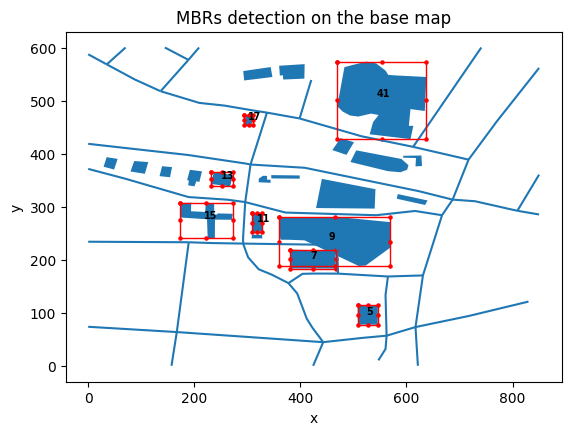

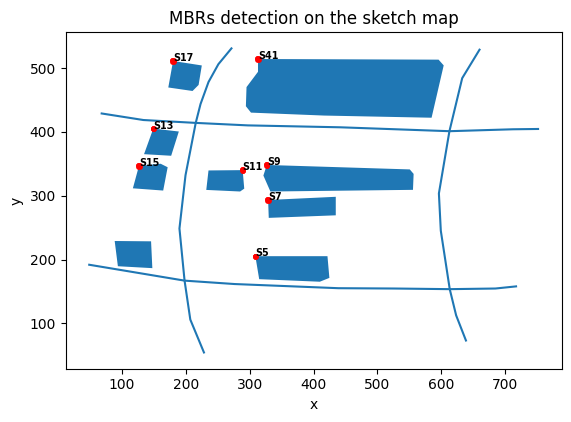

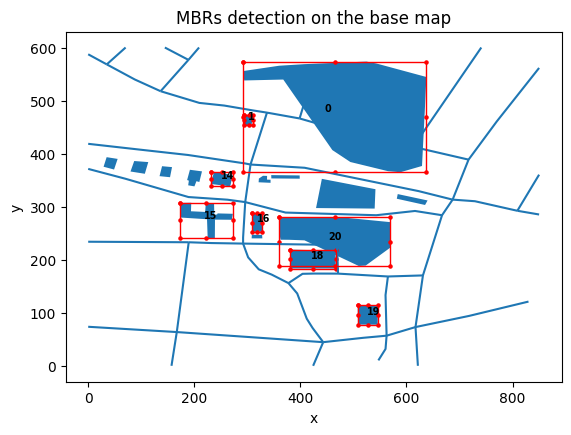

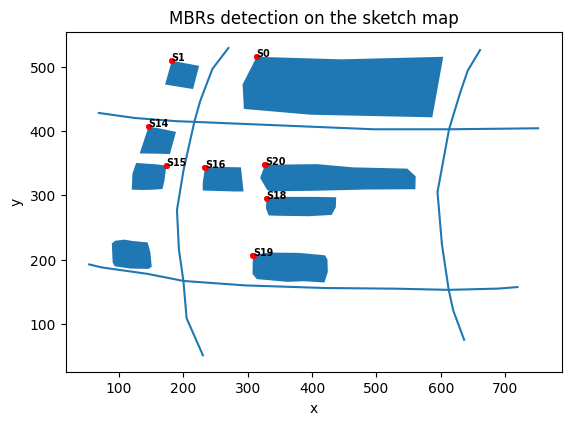

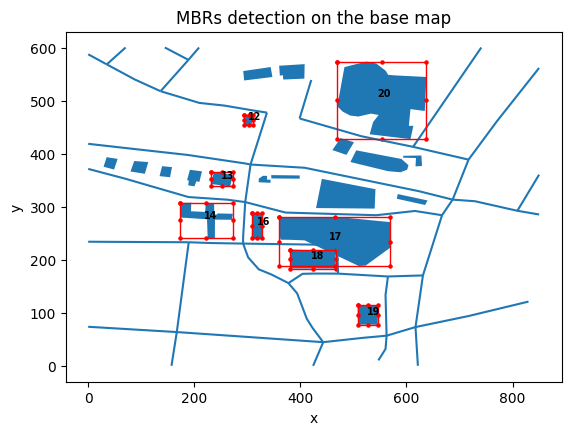

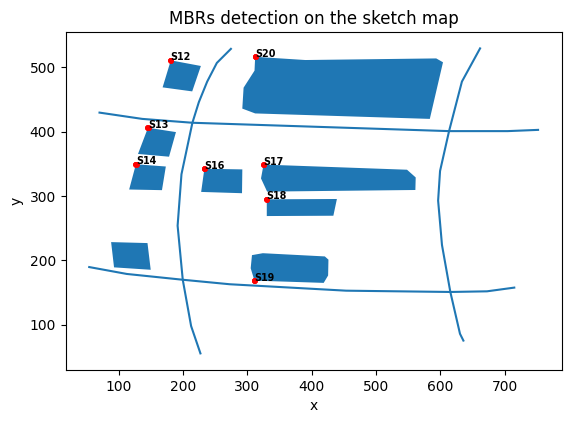

In [8]:
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import numpy as np
import math


results_charu = pd.DataFrame(columns=['Location', 'XX', 'Skm', 'nTL', 'nDL', 'CanOrg', 'CanAcc', 'ScBias', 'DistAcc', 'RotBias', 'AngAcc'])
pd.set_option('display.max_rows', None)

for loc in range(3, 4):
    for xx in ['AS', 'CM', 'JK']:
        for skm_id in range(2, 3):

            # Preparation of the Charu's dataset
            bsm_data = gpd.read_file("./datasets/LocationsCorrectedMerged/Location" + str(loc) + "_gen/_location" + str(loc) + "_" + xx + "_Sketch_" + str(skm_id) + ".jpg.geojson")
            skm_data = gpd.read_file("./datasets/LocationsCorrectedMerged/Location" + str(loc) + "_gen/" + xx + "_Sketch_" + str(skm_id) + ".jpg.geojson")

            # MBRs computation for the base map
            bsm_dict_mbr = {}
            dict_align = {}
            for i in range(bsm_data.shape[0]):
                if bsm_data[['aligned']].iloc[i, 0] and bsm_data[['otype']].iloc[i, 0] in ['Polygon', 'CircleMarker']:
                    id_poly = bsm_data[['id']].iloc[i, 0]
                    linked_skm_data = bsm_data[['SketchAlign']].iloc[i, 0]
                    if len(linked_skm_data) > 1: # many:1 or many:many association => TO IGNORE
                        continue
                    dict_align[id_poly] = int(linked_skm_data[0][1:]) # landmark id on sketch map saved without 'S'
                    coords_poly = list(bsm_data[['geometry']].iloc[i, 0].exterior.coords)
                    x_min, y_min = np.inf, np.inf
                    x_max, y_max = -np.inf, -np.inf
                    for coords in coords_poly:
                        x, y = coords
                        if x < x_min:
                            x_min = x
                        if x > x_max:
                            x_max = x
                        if y < y_min:
                            y_min = y
                        if y > y_max:
                            y_max = y
                    up_left, up_right, down_left, down_right = [x_min, y_max], [x_max, y_max], [x_min, y_min], [x_max, y_min]
                    up_center = [(x_min + x_max) / 2, y_max]
                    down_center = [(x_min + x_max) / 2, y_min]
                    left_center = [x_min, (y_min + y_max) / 2]
                    right_center = [x_max, (y_min + y_max) / 2]
                    bsm_dict_mbr[id_poly] = np.array([up_left, up_center, up_right, right_center, down_right, down_center, down_left, left_center, up_left])
            bsm_data.plot()
            for id in bsm_dict_mbr.keys():
                X, Y = [], []
                for point in bsm_dict_mbr[id]:
                    x, y = point
                    X.append(x)
                    Y.append(y)
                    plt.scatter(x, y, c='r', s=5)
                plt.plot(X, Y, c='r', lw=1)
                plt.text(np.mean(X), np.mean(Y), str(id), weight="bold", size="x-small")
            plt.title('MBRs detection on the base map')
            plt.xlabel('x')
            plt.ylabel('y')
            ax = plt.gca()
            ax.set_aspect('equal')


            # MBRs computation for the sketch map
            skm_dict_mbr = {}
            for i in range(skm_data.shape[0]):
                if skm_data[['aligned']].iloc[i, 0] and skm_data[['otype']].iloc[i, 0] in ['Polygon', 'CircleMarker']:
                    id_poly = skm_data[['id']].iloc[i, 0]
                    if not id_poly in dict_align.values(): # if this landmark is not considered on the sketch map
                        continue
                    if skm_data[['otype']].iloc[i, 0] == 'Line': # type Polygon
                        coords_poly = list(skm_data[['geometry']].iloc[i, 0].exterior.coords)
                        x_min, y_min = np.inf, np.inf
                        x_max, y_max = -np.inf, -np.inf
                        for coords in coords_poly:
                            x, y = coords
                            if x < x_min:
                                x_min = x
                            if x > x_max:
                                x_max = x
                            if y < y_min:
                                y_min = y
                            if y > y_max:
                                y_max = y
                        up_left, up_right, down_left, down_right = [x_min, y_max], [x_max, y_max], [x_min, y_min], [x_max, y_min]
                        up_center = [(x_min + x_max) / 2, y_max]
                        down_center = [(x_min + x_max) / 2, y_min]
                        left_center = [x_min, (y_min + y_max) / 2]
                        right_center = [x_max, (y_min + y_max) / 2]
                        skm_dict_mbr[id_poly] = np.array([up_left, up_center, up_right, right_center, down_right, down_center, down_left, left_center, up_left])
                    else: # type CircleMarker
                        r_buffer = 1 # buffer around the point
                        x, y = list(skm_data[['geometry']].iloc[i, 0].exterior.coords)[0] # only 1 point
                        x_min, x_max, y_min, y_max = x - r_buffer, x + r_buffer, y - r_buffer, y + r_buffer
                        up_left, up_right, down_left, down_right = [x_min, y_max], [x_max, y_max], [x_min, y_min], [x_max, y_min]
                        up_center = [(x_min + x_max) / 2, y_max]
                        down_center = [(x_min + x_max) / 2, y_min]
                        left_center = [x_min, (y_min + y_max) / 2]
                        right_center = [x_max, (y_min + y_max) / 2]
                        skm_dict_mbr[id_poly] = np.array([up_left, up_center, up_right, right_center, down_right, down_center, down_left, left_center, up_left])
            skm_data.plot()
            for id in skm_dict_mbr.keys():
                X, Y = [], []
                for point in skm_dict_mbr[id]:
                    x, y = point
                    X.append(x)
                    Y.append(y)
                    plt.scatter(x, y, c='r', s=5)
                plt.plot(X, Y, c='r', lw=1)
                plt.text(np.mean(X), np.mean(Y), f"S{str(id)}", weight="bold", size="x-small")
            plt.title('MBRs detection on the sketch map')
            plt.xlabel('x')
            plt.ylabel('y')
            ax = plt.gca()
            ax.set_aspect('equal')


            # GMDA measures

            nTL = bsm_data[(bsm_data['otype'] == 'Polygon') & (~(bsm_data['SketchAlign'].map(len, na_action='ignore') > 1))].shape[0]
            nDL = len(dict_align.keys())
            n_nTL = math.comb(8*nTL, 2) - nTL*math.comb(8, 2)
            n_nDL = math.comb(8*nDL, 2) - nDL*math.comb(8, 2)

            sum_can_score = 0 # for CanOrg & CanAcc
            max_D_bsm, max_D_skm = 0, 0 # for ScBias & DistAcc
            sum_sin, sum_cos, sum_diff_abs = 0, 0, 0 # for RotBias & AngAcc
            for i in range(nDL-1): # for every drawn landmark except the last (all combinations already tested)
                k1 = list(dict_align.keys())[i]
                b1_pts = bsm_dict_mbr[k1]
                if not dict_align[k1] in skm_dict_mbr.keys(): # if sid in alignment file but not in GeoJSON
                    print("Warning: sid in alignm but not in GeoJSON for", loc, xx, skm_id)
                    continue
                s1_pts = skm_dict_mbr[dict_align[k1]]
                k_to_explore = list(dict_align.keys())[i+1:] # explore all the not yet tested comparisons
                for k2 in k_to_explore:
                    b2_pts = bsm_dict_mbr[k2]
                    if not dict_align[k2] in skm_dict_mbr.keys(): # if sid in alignment file but not in GeoJSON
                        print("Warning: id in alignm but not in GeoJSON for", loc, xx, skm_id)
                        continue
                    s2_pts = skm_dict_mbr[dict_align[k2]]
                    for j in range(8): # 8 vertices for each MBR
                        b1_x, b1_y = b1_pts[j]
                        s1_x, s1_y = s1_pts[j]
                        for l in range(8):
                            b2_x, b2_y = b2_pts[l]
                            s2_x, s2_y = s2_pts[l]
                            ## CanOrg & CanAcc: NS comparison
                            if (b1_y < b2_y and s1_y < s2_y) or (b1_y > b2_y and s1_y > s2_y):
                                sum_can_score += 1
                            ## CanOrg & CanAcc: EW comparison
                            if (b1_x < b2_x and s1_x < s2_x) or (b1_x > b2_x and s1_x > s2_x):
                                sum_can_score += 1
                            ## ScBias & DistAcc: maximum distances on the base & sketch maps
                            dist_bsm = np.sqrt( (b1_x-b2_x)**2 + (b1_y-b2_y)**2 )
                            dist_skm = np.sqrt( (s1_x-s2_x)**2 + (s1_y-s2_y)**2 )
                            if dist_bsm > max_D_bsm:
                                max_D_bsm = dist_bsm
                            if dist_skm > max_D_skm:
                                max_D_skm = dist_skm
                            ## RotBias & AngAcc: angles comparison
                            ang_bsm = np.arctan2(b2_x-b1_x, b2_y-b1_y)
                            ang_skm = np.arctan2(s2_x-s1_x, s2_y-s1_y)
                            ang_diff = ang_skm - ang_bsm
                            while ang_diff < -np.pi:
                                ang_diff += 2*np.pi
                            while ang_diff > np.pi:
                                ang_diff -= 2*np.pi
                            sum_sin += np.sin(ang_diff)
                            sum_cos += np.cos(ang_diff)
                            sum_diff_abs += np.abs( 180 / np.pi * ang_diff )

            ## ScBias & DistAcc: scale factors comparison
            sum_dr_diff, sum_dr_diff_abs = 0, 0
            for i in range(nDL-1): # for every drawn landmark except the last (all combinations already tested)
                k1 = list(dict_align.keys())[i]
                b1_pts = bsm_dict_mbr[k1]
                if not dict_align[k1] in skm_dict_mbr.keys(): # if sid in alignment file but not in GeoJSON
                    continue
                s1_pts = skm_dict_mbr[dict_align[k1]]
                k_to_explore = list(dict_align.keys())[i+1:] # explore all the not yet tested comparisons
                for k2 in k_to_explore:
                    b2_pts = bsm_dict_mbr[k2]
                    if not dict_align[k2] in skm_dict_mbr.keys(): # if sid in alignment file but not in GeoJSON
                        continue
                    s2_pts = skm_dict_mbr[dict_align[k2]]
                    for j in range(8): # 8 vertices for each MBR
                        b1_x, b1_y = b1_pts[j]
                        s1_x, s1_y = s1_pts[j]
                        for l in range(8):
                            b2_x, b2_y = b2_pts[l]
                            s2_x, s2_y = s2_pts[l]
                            dist_bsm = np.sqrt( (b1_x-b2_x)**2 + (b1_y-b2_y)**2 )
                            dist_skm = np.sqrt( (s1_x-s2_x)**2 + (s1_y-s2_y)**2 )
                            sum_dr_diff += dist_skm / max_D_skm - dist_bsm / max_D_bsm
                            sum_dr_diff_abs += np.abs( dist_skm / max_D_skm - dist_bsm / max_D_bsm )

            can_org = sum_can_score / (2*n_nTL)
            can_acc = sum_can_score / (2*n_nDL)
            sc_bias = sum_dr_diff / n_nDL
            dist_acc = 1 - sum_dr_diff_abs / n_nDL
            rot_bias = 180 / np.pi * np.arctan2(sum_sin/n_nDL, sum_cos/n_nDL)
            ang_acc = 1 - sum_diff_abs / (180 * n_nDL)

            results_charu.loc[len(results_charu)] = [loc, xx, skm_id, nTL, nDL, np.round(can_org, 2), np.round(can_acc, 2), np.round(sc_bias, 2), np.round(dist_acc, 2), np.round(rot_bias, 2), np.round(ang_acc, 2)]
            print("Done for", loc, xx, skm_id)
            """
            print(f"CanOrg = {np.round(can_org, 2)}")
            print(f"CanAcc = {np.round(can_acc, 2)}")
            print(f"ScBias = {np.round(sc_bias, 2)}")
            print(f"DistAcc = {np.round(dist_acc, 2)}")
            print(f"RotBias = {np.round(rot_bias, 2)}°")
            print(f"AngAcc = {np.round(ang_acc, 2)}")
            """

results_charu.to_csv("results_charu.csv", index=False)

## Junctions detection: with generalization

{'JB0': [(296.0, 308.626925), [5, 0, 1, 110150]], 'JB1': [(443.0, 44.561543), [5, 6, 8, 9]], 'JB2': [(306.0, 379.424791), [1, 3, 4, 110123]], 'JB3': [(687.0, 313.266196), [3, 110129, 110131, 110157]], 'JB4': [(337.0, 477.282196), [4, 110124, 110141]], 'JB5': [(562.5, 56.78457), [6, 110147, 110148, 110149]], 'JB6': [(167.0, 63.620422), [9, 110143, 110145, 110146]], 'JB7': [(398.5, 466.27175), [110124, 110125, 110126]], 'JB8': [(612.5, 412.756555), [110126, 110127, 110128]], 'JB9': [(717.0, 388.668711), [110128, 110129, 110130]], 'JB10': [(809.0, 292.244354), [110131, 110132, 110133]], 'JB11': [(617.0, 73.036377), [110134, 110147, 110155, 110158]], 'JB12': [(35.0, 568.204798), [110135, 110136, 110137]], 'JB13': [(136.5, 517.640696), [110137, 110138, 110141]], 'JB14': [(189.0, 576.696726), [110138, 110139, 110140]], 'JB15': [(189.5, 232.906602), [110142, 110143, 110144]], 'JB16': [(292.0, 230.404228), [110142, 110151]], 'JB17': [(565.0, 168.390458), [110149, 110152, 110153]], 'JB18': [(66

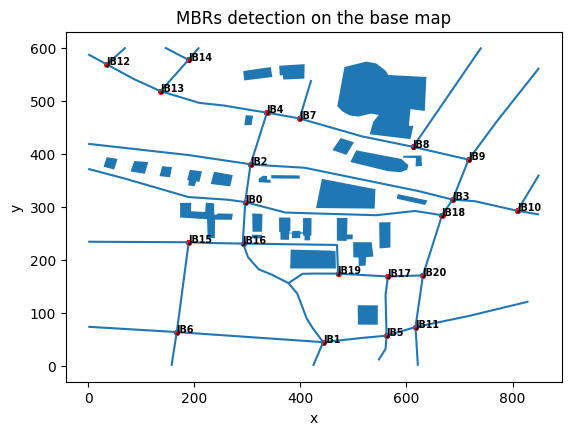

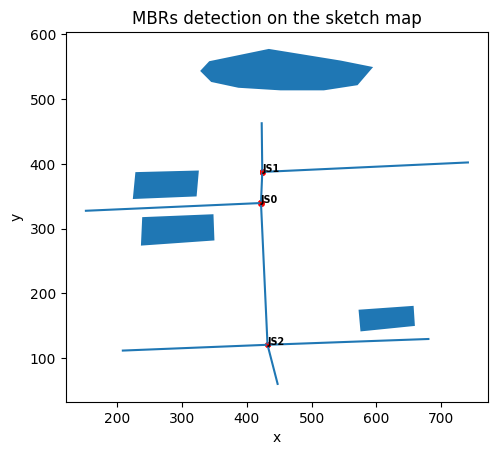

In [11]:
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import numpy as np
import math


results_charu = pd.DataFrame(columns=['Location', 'XX', 'Skm', 'nTL', 'nDL', 'CanOrg', 'CanAcc', 'ScBias', 'DistAcc', 'RotBias', 'AngAcc'])
pd.set_option('display.max_rows', None)

for loc in range(3, 4):
    for xx in ['AS']:
        for skm_id in range(7, 8):

            # Preparation of the Charu's dataset
            bsm_data = gpd.read_file("./datasets/LocationsCorrectedMerged/Location" + str(loc) + "_gen/_location" + str(loc) + "_" + xx + "_Sketch_" + str(skm_id) + ".jpg.geojson")
            skm_data = gpd.read_file("./datasets/LocationsCorrectedMerged/Location" + str(loc) + "_gen/" + xx + "_Sketch_" + str(skm_id) + ".jpg.geojson")
            

            # Junctions detection on the base map
            bsm_junctions = {}
            bsm_dict_mbr = {}
            bsm_lines = bsm_data.loc[(bsm_data['otype'] == 'Line') & (~(bsm_data['SketchAlign'].map(len, na_action='ignore') > 1))] # new dataset with 1:1 aligned roads only
            jb_id = 0 # self-generated id for the junctions on the base map
            for i in range(bsm_lines.shape[0]): # for each line
                l1_id = int(bsm_lines[['id']].iloc[i, 0])
                l1_coords = list(bsm_lines[['geometry']].iloc[i, 0].coords)
                l1_ends = [l1_coords[0], l1_coords[-1]] # only the first and last points of the line
                for j in range(i+1, bsm_lines.shape[0]): # for each other unexplored line
                    l2_id = int(bsm_lines[['id']].iloc[j, 0])
                    l2_coords = list(bsm_lines[['geometry']].iloc[j, 0].coords)
                    l2_ends = [l2_coords[0], l2_coords[-1]]
                    for end1 in l1_ends: # try to find a common end between l1 & l2
                        for end2 in l2_ends:
                            if end1 == end2:
                                new_junc = True # in a first time, suppose that the junction is new
                                for junc in bsm_junctions.keys():
                                    if end1 == bsm_junctions[junc][0]: # if this junction was already detected
                                        if l1_id in bsm_junctions[junc][1] and not l2_id in bsm_junctions[junc][1]: # add the missing id to the line ids
                                            bsm_junctions[junc][1].append(l2_id)
                                        elif l2_id in bsm_junctions[junc][1] and not l1_id in bsm_junctions[junc][1]:
                                            bsm_junctions[junc][1].append(l1_id)
                                        new_junc = False # finally this junction is already known
                                        continue
                                if new_junc: # if finally this junction is really new
                                    bsm_junctions['JB'+str(jb_id)] = [end1, [l1_id, l2_id]] # add [JBx]: [[coords], [id_lines]] in bsm_junctions
                                    jb_id += 1
            for junc in bsm_junctions.keys():
                r_buffer = 1 # buffer around the point
                x, y = bsm_junctions[junc][0]
                x_min, x_max, y_min, y_max = x - r_buffer, x + r_buffer, y - r_buffer, y + r_buffer
                up_left, up_right, down_left, down_right = [x_min, y_max], [x_max, y_max], [x_min, y_min], [x_max, y_min]
                up_center = [(x_min + x_max) / 2, y_max]
                down_center = [(x_min + x_max) / 2, y_min]
                left_center = [x_min, (y_min + y_max) / 2]
                right_center = [x_max, (y_min + y_max) / 2]
                bsm_dict_mbr[junc] = np.array([up_left, up_center, up_right, right_center, down_right, down_center, down_left, left_center, up_left])

            
            # Junctions detection on the sketch map
            skm_junctions = {}
            skm_dict_mbr = {}
            skm_lines = skm_data.loc[(skm_data['aligned'] == True) & (skm_data['otype'] == 'Line')]
            skm_lines = skm_lines[skm_lines['id'].isin([int(id) for id in list(bsm_lines['id'])])] # new dataset with 1:1 aligned roads only
            js_id = 0 # self-generated id for the junctions on the base map
            for i in range(skm_lines.shape[0]): # for each line
                l1_id = int(skm_lines[['id']].iloc[i, 0])
                l1_coords = list(skm_lines[['geometry']].iloc[i, 0].coords)
                l1_ends = [l1_coords[0], l1_coords[-1]] # only the first and last points of the line
                for j in range(i+1, skm_lines.shape[0]): # for each other unexplored line
                    l2_id = int(skm_lines[['id']].iloc[j, 0])
                    l2_coords = list(skm_lines[['geometry']].iloc[j, 0].coords)
                    l2_ends = [l2_coords[0], l2_coords[-1]]
                    for end1 in l1_ends: # try to find a common end between l1 & l2
                        for end2 in l2_ends:
                            if end1 == end2:
                                new_junc = True # in a first time, suppose that the junction is new
                                for junc in skm_junctions.keys():
                                    if end1 == skm_junctions[junc][0]: # if this junction was already detected
                                        if l1_id in skm_junctions[junc][1] and not l2_id in skm_junctions[junc][1]: # add the missing id to the line ids
                                            skm_junctions[junc][1].append(l2_id)
                                        elif l2_id in skm_junctions[junc][1] and not l1_id in skm_junctions[junc][1]:
                                            skm_junctions[junc][1].append(l1_id)
                                        new_junc = False # finally this junction is already known
                                        continue
                                if new_junc: # if finally this junction is really new
                                    skm_junctions['JS'+str(js_id)] = [end1, [l1_id, l2_id]] # add [JSx]: [[coords], [id_lines]] in skm_junctions
                                    js_id += 1
            for junc in skm_junctions.keys():
                r_buffer = 1 # buffer around the point
                x, y = skm_junctions[junc][0]
                x_min, x_max, y_min, y_max = x - r_buffer, x + r_buffer, y - r_buffer, y + r_buffer
                up_left, up_right, down_left, down_right = [x_min, y_max], [x_max, y_max], [x_min, y_min], [x_max, y_min]
                up_center = [(x_min + x_max) / 2, y_max]
                down_center = [(x_min + x_max) / 2, y_min]
                left_center = [x_min, (y_min + y_max) / 2]
                right_center = [x_max, (y_min + y_max) / 2]
                skm_dict_mbr[junc] = np.array([up_left, up_center, up_right, right_center, down_right, down_center, down_left, left_center, up_left])


            # Alignment management
            dict_align = {}
            for bsm_junc in bsm_junctions.keys():
                bsm_id_lines = bsm_junctions[bsm_junc][1]
                for skm_junc in skm_junctions.keys():
                    skm_id_lines = skm_junctions[skm_junc][1]
                    if set(skm_id_lines) <= set(bsm_id_lines): # if all the skm_id_lines included in bsm_id_lines
                        dict_align[bsm_junc] = skm_junc

            
            # Plots
            bsm_data.plot()
            for id in bsm_dict_mbr.keys():
                X, Y = [], []
                for point in bsm_dict_mbr[id]:
                    x, y = point
                    X.append(x)
                    Y.append(y)
                    plt.scatter(x, y, c='r', s=5)
                plt.plot(X, Y, c='r', lw=1)
                plt.text(np.mean(X), np.mean(Y), str(id), weight="bold", size="x-small")
            plt.title('MBRs detection on the base map')
            plt.xlabel('x')
            plt.ylabel('y')
            ax = plt.gca()
            ax.set_aspect('equal')

            skm_data.plot()
            for id in skm_dict_mbr.keys():
                X, Y = [], []
                for point in skm_dict_mbr[id]:
                    x, y = point
                    X.append(x)
                    Y.append(y)
                    plt.scatter(x, y, c='r', s=5)
                plt.plot(X, Y, c='r', lw=1)
                plt.text(np.mean(X), np.mean(Y), str(id), weight="bold", size="x-small")
            plt.title('MBRs detection on the sketch map')
            plt.xlabel('x')
            plt.ylabel('y')
            ax = plt.gca()
            ax.set_aspect('equal')
            
            print(bsm_junctions)
            print(skm_junctions)
            print(dict_align)

            
            # GMDA measures

            nTL = len(bsm_junctions.keys())
            nDL = len(dict_align.keys())
            n_nTL = math.comb(8*nTL, 2) - nTL*math.comb(8, 2)
            n_nDL = math.comb(8*nDL, 2) - nDL*math.comb(8, 2)

            if nDL < 2: # not enough drawn landmarks => impossible to calculate
                print("ERROR: not enough landmarks for", loc, xx, skm_id)
                results_charu.loc[len(results_charu)] = [loc, xx, skm_id, 'NULL', 'NULL', 'NULL', 'NULL', 'NULL', 'NULL', 'NULL', 'NULL']
                continue
            sum_can_score = 0 # for CanOrg & CanAcc
            max_D_bsm, max_D_skm = 0, 0 # for ScBias & DistAcc
            sum_sin, sum_cos, sum_diff_abs = 0, 0, 0 # for RotBias & AngAcc
            for i in range(nDL-1): # for every drawn landmark except the last (all combinations already tested)
                k1 = list(dict_align.keys())[i]
                b1_pts = bsm_dict_mbr[k1]
                if not dict_align[k1] in skm_dict_mbr.keys(): # if sid in alignment file but not in GeoJSON
                    print("Warning: sid in alignm but not in GeoJSON for", loc, xx, skm_id)
                    continue
                s1_pts = skm_dict_mbr[dict_align[k1]]
                k_to_explore = list(dict_align.keys())[i+1:] # explore all the not yet tested comparisons
                for k2 in k_to_explore:
                    b2_pts = bsm_dict_mbr[k2]
                    if not dict_align[k2] in skm_dict_mbr.keys(): # if sid in alignment file but not in GeoJSON
                        print("Warning: id in alignm but not in GeoJSON for", loc, xx, skm_id)
                        continue
                    s2_pts = skm_dict_mbr[dict_align[k2]]
                    for j in range(8): # 8 vertices for each MBR
                        b1_x, b1_y = b1_pts[j]
                        s1_x, s1_y = s1_pts[j]
                        for l in range(8):
                            b2_x, b2_y = b2_pts[l]
                            s2_x, s2_y = s2_pts[l]
                            ## CanOrg & CanAcc: NS comparison
                            if (b1_y < b2_y and s1_y < s2_y) or (b1_y > b2_y and s1_y > s2_y):
                                sum_can_score += 1
                            ## CanOrg & CanAcc: EW comparison
                            if (b1_x < b2_x and s1_x < s2_x) or (b1_x > b2_x and s1_x > s2_x):
                                sum_can_score += 1
                            ## ScBias & DistAcc: maximum distances on the base & sketch maps
                            dist_bsm = np.sqrt( (b1_x-b2_x)**2 + (b1_y-b2_y)**2 )
                            dist_skm = np.sqrt( (s1_x-s2_x)**2 + (s1_y-s2_y)**2 )
                            if dist_bsm > max_D_bsm:
                                max_D_bsm = dist_bsm
                            if dist_skm > max_D_skm:
                                max_D_skm = dist_skm
                            ## RotBias & AngAcc: angles comparison
                            ang_bsm = np.arctan2(b2_x-b1_x, b2_y-b1_y)
                            ang_skm = np.arctan2(s2_x-s1_x, s2_y-s1_y)
                            ang_diff = ang_skm - ang_bsm
                            while ang_diff < -np.pi:
                                ang_diff += 2*np.pi
                            while ang_diff > np.pi:
                                ang_diff -= 2*np.pi
                            sum_sin += np.sin(ang_diff)
                            sum_cos += np.cos(ang_diff)
                            sum_diff_abs += np.abs( 180 / np.pi * ang_diff )

            ## ScBias & DistAcc: scale factors comparison
            sum_dr_diff, sum_dr_diff_abs = 0, 0
            for i in range(nDL-1): # for every drawn landmark except the last (all combinations already tested)
                k1 = list(dict_align.keys())[i]
                b1_pts = bsm_dict_mbr[k1]
                if not dict_align[k1] in skm_dict_mbr.keys(): # if sid in alignment file but not in GeoJSON
                    continue
                s1_pts = skm_dict_mbr[dict_align[k1]]
                k_to_explore = list(dict_align.keys())[i+1:] # explore all the not yet tested comparisons
                for k2 in k_to_explore:
                    b2_pts = bsm_dict_mbr[k2]
                    if not dict_align[k2] in skm_dict_mbr.keys(): # if sid in alignment file but not in GeoJSON
                        continue
                    s2_pts = skm_dict_mbr[dict_align[k2]]
                    for j in range(8): # 8 vertices for each MBR
                        b1_x, b1_y = b1_pts[j]
                        s1_x, s1_y = s1_pts[j]
                        for l in range(8):
                            b2_x, b2_y = b2_pts[l]
                            s2_x, s2_y = s2_pts[l]
                            dist_bsm = np.sqrt( (b1_x-b2_x)**2 + (b1_y-b2_y)**2 )
                            dist_skm = np.sqrt( (s1_x-s2_x)**2 + (s1_y-s2_y)**2 )
                            sum_dr_diff += dist_skm / max_D_skm - dist_bsm / max_D_bsm
                            sum_dr_diff_abs += np.abs( dist_skm / max_D_skm - dist_bsm / max_D_bsm )

            can_org = sum_can_score / (2*n_nTL)
            can_acc = sum_can_score / (2*n_nDL)
            sc_bias = sum_dr_diff / n_nDL
            dist_acc = 1 - sum_dr_diff_abs / n_nDL
            rot_bias = 180 / np.pi * np.arctan2(sum_sin/n_nDL, sum_cos/n_nDL)
            ang_acc = 1 - sum_diff_abs / (180 * n_nDL)

            results_charu.loc[len(results_charu)] = [loc, xx, skm_id, nTL, nDL, np.round(can_org, 2), np.round(can_acc, 2), np.round(sc_bias, 2), np.round(dist_acc, 2), np.round(rot_bias, 2), np.round(ang_acc, 2)]
            print("Done for", loc, xx, skm_id)
            
            print(f"CanOrg = {np.round(can_org, 2)}")
            print(f"CanAcc = {np.round(can_acc, 2)}")
            print(f"ScBias = {np.round(sc_bias, 2)}")
            print(f"DistAcc = {np.round(dist_acc, 2)}")
            print(f"RotBias = {np.round(rot_bias, 2)}°")
            print(f"AngAcc = {np.round(ang_acc, 2)}")


results_charu.to_csv("results_charu.csv", index=False)

## Both detection: with generalization

d:\anaconda3\envs\geospatial\Lib\site-packages\geopandas\io\file.py:576: UserWarning: Could not parse column 'id' as JSON; leaving as string
  return pyogrio.read_dataframe(path_or_bytes, bbox=bbox, **kwargs)


Done for 5 AS 4
CanOrg = 0.04
CanAcc = 0.96
ScBias = 0.01
DistAcc = 0.94
RotBias = -3.12°
AngAcc = 0.96
{'JB0': 'JS0', 'JB1': 'JS1', 'JB2': 'JS2', 'JB3': 'JS4', 'JB4': 'JS3', 'JB5': 'JS5'}


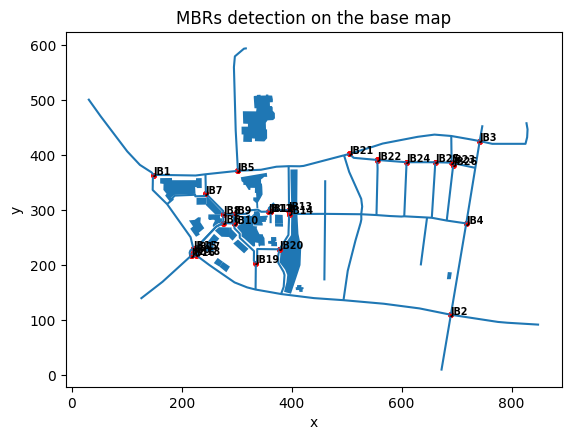

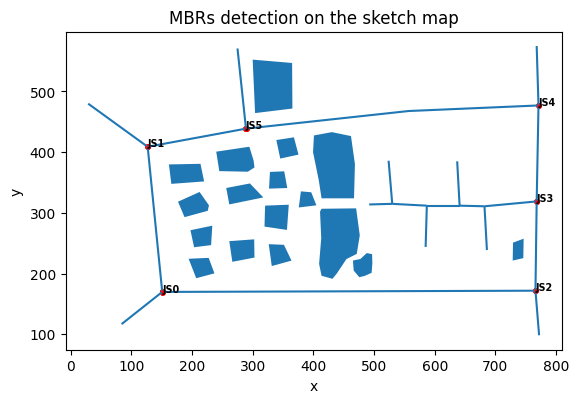

In [36]:
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd
import numpy as np
import shapely
import math
import os

# TO CHOOSE ('poly', 'line', 'both')
mode = "line"

results_charu = pd.DataFrame(columns=['Location', 'XX', 'Skm', 'nTL', 'nDL', 'CanOrg', 'CanAcc', 'ScBias', 'DistAcc', 'RotBias', 'AngAcc'])
pd.set_option('display.max_rows', None)

for loc in [5]:
    for xx in ['AS']:
        for skm_id in range(4, 5):

            # ----- PREPARATION OF THE DATASET -----

            geojson_path = "./datasets/LocationsCorrectedMerged/Location" + str(loc) + "_gen/_location" + str(loc) + "_" + xx + "_Sketch_" + str(skm_id) + ".jpg.geojson"
            if os.path.exists(geojson_path): # if base map image saved as JPG
                bsm_data = gpd.read_file(geojson_path)
            else:
                bsm_data = gpd.read_file("./datasets/LocationsCorrectedMerged/Location" + str(loc) + "_gen/_location" + str(loc) + "_" + xx + "_Sketch_" + str(skm_id) + ".png.geojson")
            skm_data = gpd.read_file("./datasets/LocationsCorrectedMerged/Location" + str(loc) + "_gen/" + xx + "_Sketch_" + str(skm_id) + ".jpg.geojson")


            # ----- LANDMARKS DETECTION ON THE BASE MAP -----

            bsm_dict_mbr = {}
            dict_align = {}

            # Polygons
            if mode != "line":
                bsm_polys = bsm_data.loc[(bsm_data['otype'] == 'Polygon') & (~(bsm_data['SketchAlign'].map(len, na_action='ignore') > 1))]
                for i in range(bsm_polys.shape[0]):
                    id_poly = int(bsm_polys[['id']].iloc[i, 0])
                    coords_poly = list(bsm_polys[['geometry']].iloc[i, 0].exterior.coords)
                    x_min, y_min = np.inf, np.inf
                    x_max, y_max = -np.inf, -np.inf
                    for coords in coords_poly:
                        x, y = coords
                        if x < x_min:
                            x_min = x
                        if x > x_max:
                            x_max = x
                        if y < y_min:
                            y_min = y
                        if y > y_max:
                            y_max = y
                    up_left, up_right, down_left, down_right = [x_min, y_max], [x_max, y_max], [x_min, y_min], [x_max, y_min]
                    up_center = [(x_min + x_max) / 2, y_max]
                    down_center = [(x_min + x_max) / 2, y_min]
                    left_center = [x_min, (y_min + y_max) / 2]
                    right_center = [x_max, (y_min + y_max) / 2]
                    bsm_dict_mbr[id_poly] = np.array([up_left, up_center, up_right, right_center, down_right, down_center, down_left, left_center, up_left])
                    if bsm_polys[['aligned']].iloc[i, 0]:
                        dict_align[id_poly] = int(bsm_polys[['SketchAlign']].iloc[i, 0][0][1:]) # landmark id on sketch map saved without 'S'

            # Junctions
            if mode != "poly":
                bsm_junctions = {}
                bsm_lines = bsm_data.loc[(bsm_data['otype'] == 'Line') & (~(bsm_data['SketchAlign'].map(len, na_action='ignore') > 1))] # new dataset with 1:1 aligned roads only
                jb_id = 0 # self-generated id for the junctions on the base map
                for i in range(bsm_lines.shape[0]): # for each line
                    l1_id = int(bsm_lines[['id']].iloc[i, 0])
                    l1_coords = shapely.get_coordinates(bsm_lines[['geometry']].iloc[i, 0]).tolist()
                    l1_ends = [l1_coords[0], l1_coords[-1]] # only the first and last points of the line
                    for j in range(i+1, bsm_lines.shape[0]): # for each other unexplored line
                        l2_id = int(bsm_lines[['id']].iloc[j, 0])
                        l2_coords = shapely.get_coordinates(bsm_lines[['geometry']].iloc[j, 0]).tolist()
                        l2_ends = [l2_coords[0], l2_coords[-1]]
                        for end1 in l1_ends: # try to find a common end between l1 & l2
                            for end2 in l2_ends:
                                if end1 == end2:
                                    new_junc = True # in a first time, suppose that the junction is new
                                    for junc in bsm_junctions.keys():
                                        if end1 == bsm_junctions[junc][0]: # if this junction was already detected
                                            if l1_id in bsm_junctions[junc][1] and not l2_id in bsm_junctions[junc][1]: # add the missing id to the line ids
                                                bsm_junctions[junc][1].append(l2_id)
                                            elif l2_id in bsm_junctions[junc][1] and not l1_id in bsm_junctions[junc][1]:
                                                bsm_junctions[junc][1].append(l1_id)
                                            new_junc = False # finally this junction is already known
                                            continue
                                    if new_junc: # if finally this junction is really new
                                        bsm_junctions['JB'+str(jb_id)] = [end1, [l1_id, l2_id]] # add [JBx]: [[coords], [id_lines]] in bsm_junctions
                                        jb_id += 1
                for junc in bsm_junctions.keys():
                    r_buffer = 1 # buffer around the point
                    x, y = bsm_junctions[junc][0]
                    x_min, x_max, y_min, y_max = x - r_buffer, x + r_buffer, y - r_buffer, y + r_buffer
                    up_left, up_right, down_left, down_right = [x_min, y_max], [x_max, y_max], [x_min, y_min], [x_max, y_min]
                    up_center = [(x_min + x_max) / 2, y_max]
                    down_center = [(x_min + x_max) / 2, y_min]
                    left_center = [x_min, (y_min + y_max) / 2]
                    right_center = [x_max, (y_min + y_max) / 2]
                    bsm_dict_mbr[junc] = np.array([up_left, up_center, up_right, right_center, down_right, down_center, down_left, left_center, up_left])
            

            # ----- LANDMARKS DETECTION ON THE SKETCH MAP -----

            skm_dict_mbr = {}

            # Polygons
            if mode != "line":
                skm_polys = skm_data.loc[(skm_data['aligned'] == True) & ((skm_data['otype'] == 'Polygon') | (skm_data['otype'] == 'CircleMarker'))]
                skm_polys = skm_polys[skm_polys['id'].isin(dict_align.values())]
                for i in range(skm_polys.shape[0]):
                    id_poly = int(skm_polys[['id']].iloc[i, 0])
                    if skm_polys[['otype']].iloc[i, 0] == 'Polygon': # type Polygon
                        coords_poly = list(skm_polys[['geometry']].iloc[i, 0].exterior.coords)
                        x_min, y_min = np.inf, np.inf
                        x_max, y_max = -np.inf, -np.inf
                        for coords in coords_poly:
                            x, y = coords
                            if x < x_min:
                                x_min = x
                            if x > x_max:
                                x_max = x
                            if y < y_min:
                                y_min = y
                            if y > y_max:
                                y_max = y
                        up_left, up_right, down_left, down_right = [x_min, y_max], [x_max, y_max], [x_min, y_min], [x_max, y_min]
                        up_center = [(x_min + x_max) / 2, y_max]
                        down_center = [(x_min + x_max) / 2, y_min]
                        left_center = [x_min, (y_min + y_max) / 2]
                        right_center = [x_max, (y_min + y_max) / 2]
                        skm_dict_mbr[id_poly] = np.array([up_left, up_center, up_right, right_center, down_right, down_center, down_left, left_center, up_left])
                    else: # type CircleMarker
                        r_buffer = 1 # buffer around the point
                        x, y = list(skm_polys[['geometry']].iloc[i, 0].coords)[0] # only 1 point
                        x_min, x_max, y_min, y_max = x - r_buffer, x + r_buffer, y - r_buffer, y + r_buffer
                        up_left, up_right, down_left, down_right = [x_min, y_max], [x_max, y_max], [x_min, y_min], [x_max, y_min]
                        up_center = [(x_min + x_max) / 2, y_max]
                        down_center = [(x_min + x_max) / 2, y_min]
                        left_center = [x_min, (y_min + y_max) / 2]
                        right_center = [x_max, (y_min + y_max) / 2]
                        skm_dict_mbr[id_poly] = np.array([up_left, up_center, up_right, right_center, down_right, down_center, down_left, left_center, up_left])

            # Junctions
            if mode != "poly":
                skm_junctions = {}
                skm_lines = skm_data.loc[(skm_data['aligned']) & (skm_data['otype'] == 'Line')]
                skm_lines = skm_lines[skm_lines['id'].isin([int(id) for id in list(bsm_lines['id'])])] # new dataset with 1:1 aligned roads only
                js_id = 0 # self-generated id for the junctions on the base map
                for i in range(skm_lines.shape[0]): # for each line
                    l1_id = int(skm_lines[['id']].iloc[i, 0])
                    l1_coords = list(skm_lines[['geometry']].iloc[i, 0].coords)
                    l1_ends = [l1_coords[0], l1_coords[-1]] # only the first and last points of the line
                    for j in range(i+1, skm_lines.shape[0]): # for each other unexplored line
                        l2_id = int(skm_lines[['id']].iloc[j, 0])
                        l2_coords = list(skm_lines[['geometry']].iloc[j, 0].coords)
                        l2_ends = [l2_coords[0], l2_coords[-1]]
                        for end1 in l1_ends: # try to find a common end between l1 & l2
                            for end2 in l2_ends:
                                if end1 == end2:
                                    new_junc = True # in a first time, suppose that the junction is new
                                    for junc in skm_junctions.keys():
                                        if end1 == skm_junctions[junc][0]: # if this junction was already detected
                                            if l1_id in skm_junctions[junc][1] and not l2_id in skm_junctions[junc][1]: # add the missing id to the line ids
                                                skm_junctions[junc][1].append(l2_id)
                                            elif l2_id in skm_junctions[junc][1] and not l1_id in skm_junctions[junc][1]:
                                                skm_junctions[junc][1].append(l1_id)
                                            new_junc = False # finally this junction is already known
                                            continue
                                    if new_junc: # if finally this junction is really new
                                        skm_junctions['JS'+str(js_id)] = [end1, [l1_id, l2_id]] # add [JSx]: [[coords], [id_lines]] in skm_junctions
                                        js_id += 1
                for junc in skm_junctions.keys():
                    r_buffer = 1 # buffer around the point
                    x, y = skm_junctions[junc][0]
                    x_min, x_max, y_min, y_max = x - r_buffer, x + r_buffer, y - r_buffer, y + r_buffer
                    up_left, up_right, down_left, down_right = [x_min, y_max], [x_max, y_max], [x_min, y_min], [x_max, y_min]
                    up_center = [(x_min + x_max) / 2, y_max]
                    down_center = [(x_min + x_max) / 2, y_min]
                    left_center = [x_min, (y_min + y_max) / 2]
                    right_center = [x_max, (y_min + y_max) / 2]
                    skm_dict_mbr[junc] = np.array([up_left, up_center, up_right, right_center, down_right, down_center, down_left, left_center, up_left])
                
                for bsm_junc in bsm_junctions.keys():
                    bsm_id_lines = bsm_junctions[bsm_junc][1]
                    for skm_junc in skm_junctions.keys():
                        skm_id_lines = skm_junctions[skm_junc][1]
                        if set(skm_id_lines) <= set(bsm_id_lines): # if all the skm_id_lines included in bsm_id_lines
                            dict_align[bsm_junc] = skm_junc

            
            # ----- PLOTS -----
            
            bsm_data.plot(aspect='equal')
            for id in bsm_dict_mbr.keys():
                X, Y = [], []
                for point in bsm_dict_mbr[id]:
                    x, y = point
                    X.append(x)
                    Y.append(y)
                    plt.scatter(x, y, c='r', s=5)
                plt.plot(X, Y, c='r', lw=1)
                plt.text(np.mean(X), np.mean(Y), str(id), weight="bold", size="x-small")
            plt.title('MBRs detection on the base map')
            plt.xlabel('x')
            plt.ylabel('y')
            ax = plt.gca()
            ax.set_aspect('equal')
            
            skm_data.plot(aspect='equal')
            for id in skm_dict_mbr.keys():
                X, Y = [], []
                for point in skm_dict_mbr[id]:
                    x, y = point
                    X.append(x)
                    Y.append(y)
                    plt.scatter(x, y, c='r', s=5)
                plt.plot(X, Y, c='r', lw=1)
                plt.text(np.mean(X), np.mean(Y), str(id), weight="bold", size="x-small")
            plt.title('MBRs detection on the sketch map')
            plt.xlabel('x')
            plt.ylabel('y')
            ax = plt.gca()
            ax.set_aspect('equal')
            
            
            # ----- GMDA MEASURES -----

            nTL = len(bsm_dict_mbr)
            nDL = len(dict_align.keys())
            n_nTL = math.comb(8*nTL, 2) - nTL*math.comb(8, 2)
            n_nDL = math.comb(8*nDL, 2) - nDL*math.comb(8, 2)

            if nDL < 2: # not enough drawn landmarks => impossible to calculate
                print("ERROR: not enough landmarks for", loc, xx, skm_id)
                results_charu.loc[len(results_charu)] = [loc, xx, skm_id, 'NULL', 'NULL', 'NULL', 'NULL', 'NULL', 'NULL', 'NULL', 'NULL']
                continue
            sum_can_score = 0 # for CanOrg & CanAcc
            max_D_bsm, max_D_skm = 0, 0 # for ScBias & DistAcc
            sum_sin, sum_cos, sum_diff_abs = 0, 0, 0 # for RotBias & AngAcc
            for i in range(nDL-1): # for every drawn landmark except the last (all combinations already tested)
                k1 = list(dict_align.keys())[i]
                b1_pts = bsm_dict_mbr[k1]
                if not dict_align[k1] in skm_dict_mbr.keys(): # if sid in alignment file but not in GeoJSON
                    print(f"Warning: sid {dict_align[k1]} in alignm but not in GeoJSON for", loc, xx, skm_id)
                    continue
                s1_pts = skm_dict_mbr[dict_align[k1]]
                k_to_explore = list(dict_align.keys())[i+1:] # explore all the not yet tested comparisons
                for k2 in k_to_explore:
                    b2_pts = bsm_dict_mbr[k2]
                    if not dict_align[k2] in skm_dict_mbr.keys(): # if sid in alignment file but not in GeoJSON
                        print(f"Warning: sid {dict_align[k2]} in alignm but not in GeoJSON for", loc, xx, skm_id)
                        continue
                    s2_pts = skm_dict_mbr[dict_align[k2]]
                    for j in range(8): # 8 vertices for each MBR
                        b1_x, b1_y = b1_pts[j]
                        s1_x, s1_y = s1_pts[j]
                        for l in range(8):
                            b2_x, b2_y = b2_pts[l]
                            s2_x, s2_y = s2_pts[l]
                            ## CanOrg & CanAcc: NS comparison
                            if (b1_y < b2_y and s1_y < s2_y) or (b1_y > b2_y and s1_y > s2_y):
                                sum_can_score += 1
                            ## CanOrg & CanAcc: EW comparison
                            if (b1_x < b2_x and s1_x < s2_x) or (b1_x > b2_x and s1_x > s2_x):
                                sum_can_score += 1
                            ## ScBias & DistAcc: maximum distances on the base & sketch maps
                            dist_bsm = np.sqrt( (b1_x-b2_x)**2 + (b1_y-b2_y)**2 )
                            dist_skm = np.sqrt( (s1_x-s2_x)**2 + (s1_y-s2_y)**2 )
                            if dist_bsm > max_D_bsm:
                                max_D_bsm = dist_bsm
                            if dist_skm > max_D_skm:
                                max_D_skm = dist_skm
                            ## RotBias & AngAcc: angles comparison
                            ang_bsm = np.arctan2(b2_x-b1_x, b2_y-b1_y)
                            ang_skm = np.arctan2(s2_x-s1_x, s2_y-s1_y)
                            ang_diff = ang_skm - ang_bsm
                            while ang_diff < -np.pi:
                                ang_diff += 2*np.pi
                            while ang_diff > np.pi:
                                ang_diff -= 2*np.pi
                            sum_sin += np.sin(ang_diff)
                            sum_cos += np.cos(ang_diff)
                            sum_diff_abs += np.abs( 180 / np.pi * ang_diff )

            ## ScBias & DistAcc: scale factors comparison
            sum_dr_diff, sum_dr_diff_abs = 0, 0
            for i in range(nDL-1): # for every drawn landmark except the last (all combinations already tested)
                k1 = list(dict_align.keys())[i]
                b1_pts = bsm_dict_mbr[k1]
                if not dict_align[k1] in skm_dict_mbr.keys(): # if sid in alignment file but not in GeoJSON
                    continue
                s1_pts = skm_dict_mbr[dict_align[k1]]
                k_to_explore = list(dict_align.keys())[i+1:] # explore all the not yet tested comparisons
                for k2 in k_to_explore:
                    b2_pts = bsm_dict_mbr[k2]
                    if not dict_align[k2] in skm_dict_mbr.keys(): # if sid in alignment file but not in GeoJSON
                        continue
                    s2_pts = skm_dict_mbr[dict_align[k2]]
                    for j in range(8): # 8 vertices for each MBR
                        b1_x, b1_y = b1_pts[j]
                        s1_x, s1_y = s1_pts[j]
                        for l in range(8):
                            b2_x, b2_y = b2_pts[l]
                            s2_x, s2_y = s2_pts[l]
                            dist_bsm = np.sqrt( (b1_x-b2_x)**2 + (b1_y-b2_y)**2 )
                            dist_skm = np.sqrt( (s1_x-s2_x)**2 + (s1_y-s2_y)**2 )
                            sum_dr_diff += dist_skm / max_D_skm - dist_bsm / max_D_bsm
                            sum_dr_diff_abs += np.abs( dist_skm / max_D_skm - dist_bsm / max_D_bsm )

            can_org = sum_can_score / (2*n_nTL)
            can_acc = sum_can_score / (2*n_nDL)
            sc_bias = sum_dr_diff / n_nDL
            dist_acc = 1 - sum_dr_diff_abs / n_nDL
            rot_bias = 180 / np.pi * np.arctan2(sum_sin/n_nDL, sum_cos/n_nDL)
            ang_acc = 1 - sum_diff_abs / (180 * n_nDL)

            results_charu.loc[len(results_charu)] = [loc, xx, skm_id, nTL, nDL, np.round(can_org, 2), np.round(can_acc, 2), np.round(sc_bias, 2), np.round(dist_acc, 2), np.round(rot_bias, 2), np.round(ang_acc, 2)]
            print("Done for", loc, xx, skm_id)
            
            print(f"CanOrg = {np.round(can_org, 2)}")
            print(f"CanAcc = {np.round(can_acc, 2)}")
            print(f"ScBias = {np.round(sc_bias, 2)}")
            print(f"DistAcc = {np.round(dist_acc, 2)}")
            print(f"RotBias = {np.round(rot_bias, 2)}°")
            print(f"AngAcc = {np.round(ang_acc, 2)}")

print(dict_align)
results_charu.to_csv("results_charu.csv", index=False)